# Sampling small MNIST posteriors: the five-step plan

The experiment runs in five steps, each building on the last:

1. **Point estimates:** train very simple NNs on MNIST, MLP vs CNN.
2. **Derivation:** the training loss and its exact relationship to the log-posterior.
3. **Ensemble baseline:** a random-seed deep ensemble, per-image probabilities with spread.
4. **Ray tracing MCMC with the Metropolis test:** full-batch gradients, exact accept/reject, step size tuned toward ~80% acceptance.
5. **ESS and uncertainty:** the chain compared against the ensemble.

Checkpoints and ensembles are loaded from `results/` when present; set `RECOMPUTE = True` to retrain them in place. The step 4 chains and tuning logs are produced by `experiments/exp6_sample_metropolis.py` (`pilot` / `auto` / `run` modes) and loaded here. The sampler is the author's released `raytrace_torch.py`, vendored unmodified.

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

sys.path.insert(0, str(Path.cwd()))                # for rts/ and plots/
import matplotlib.pyplot as plt
from plots.style import RT, HMC, BLUE, GREY
from rts.metrics import tau_sokal

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
CHECKPOINT_DIR = Path("results/checkpoints")
TABLE_DIR = Path("results/tables")
RECOMPUTE = False
SEED = 0
%matplotlib inline
print("device:", DEVICE)

device: mps


## Step 1: point estimates (MLP vs CNN)

Two deliberately small networks. Step 4 needs the exact Metropolis test, which means evaluating the log-posterior and its gradient on **all 60,000 training images** at every leapfrog step.

Recipe: Adam, lr 1e-3, batch 128, 5 epochs, seed 0, standard MNIST normalization, **no weight decay**. The no-weight-decay choice is deliberate: it makes the point estimate a pure maximum-likelihood point, so the prior enters only through the step 2 derivation and nothing is double-counted.

How to read the table below: test accuracy, higher is better; test NLL (negative log-likelihood in nats), lower is better. D is the parameter count, a size, not a score.

In [2]:
class MLP(nn.Module):
    """784 -> 64 -> 10, ReLU. 50,890 parameters."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, hidden),
                                 nn.ReLU(), nn.Linear(hidden, 10))

    def forward(self, images):
        return self.net(images)


class CNN(nn.Module):
    """conv16 -> pool -> conv32 -> pool -> linear. 12,810 parameters."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.linear = nn.Linear(32 * 5 * 5, 10)

    def forward(self, images):
        images = F.max_pool2d(F.relu(self.conv1(images)), 2)
        images = F.max_pool2d(F.relu(self.conv2(images)), 2)
        return self.linear(images.flatten(1))


ARCHITECTURES = {"mlp": MLP, "cnn": CNN}


def load_mnist(batch_size=128):
    transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST("data", train=True, download=True, transform=transform)
    test_set = datasets.MNIST("data", train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                               shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000)
    return train_loader, test_loader, len(train_set)


@torch.no_grad()
def evaluate(model, loader):
    """Accuracy, mean negative log-likelihood, probabilities, and labels."""
    model.eval()
    probability_batches, label_batches = [], []
    loss_sum, image_count = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss_sum += F.cross_entropy(logits, labels, reduction="sum").item()
        probability_batches.append(F.softmax(logits, dim=1).cpu().numpy())
        label_batches.append(labels.cpu().numpy())
        image_count += len(labels)
    probabilities = np.concatenate(probability_batches)
    labels = np.concatenate(label_batches)
    accuracy = (probabilities.argmax(axis=1) == labels).mean()
    return accuracy, loss_sum / image_count, probabilities, labels

In [3]:
def train(model, epochs=5, learning_rate=1e-3, seed=None):
    """seed=None trains with whatever random state is current (the caller seeds)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    train_loader, _, _ = load_mnist()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for _ in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            F.cross_entropy(model(images), labels).backward()
            optimizer.step()
    return model


_, test_loader, TRAINING_SET_SIZE = load_mnist()

point_estimates = {}
print(f"{'model':6s} {'D':>7s} {'test acc':>9s} {'test NLL':>9s}")
for name, architecture in ARCHITECTURES.items():
    model = architecture().to(DEVICE)
    checkpoint = CHECKPOINT_DIR / f"exp6_{name}.pt"
    if checkpoint.exists() and not RECOMPUTE:
        model.load_state_dict(torch.load(checkpoint))
    else:
        train(model, seed=SEED)
        torch.save(model.state_dict(), checkpoint)
    accuracy, negative_log_likelihood, probabilities, labels = evaluate(model,
                                                                        test_loader)
    parameter_count = sum(p.numel() for p in model.parameters())
    point_estimates[name] = dict(model=model, accuracy=accuracy,
                                 probabilities=probabilities, labels=labels,
                                 parameter_count=parameter_count)
    print(f"{name:6s} {parameter_count:7d} {accuracy:9.4f} "
          f"{negative_log_likelihood:9.4f}")

model        D  test acc  test NLL


mlp      50890    0.9734    0.0928


cnn      12810    0.9847    0.0474


## Step 2: from the training loss to the log-posterior

The network defines a categorical likelihood per image, $p(y \mid x, \theta) = \mathrm{softmax}(f_\theta(x))_y$, and the training loss is the mean cross-entropy in nats (torch uses $\ln$):

$$\mathrm{CE}(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \ln p(y_i \mid x_i, \theta), \qquad N = 60{,}000.$$

**The identity.** Because the labels are discrete, the log-likelihood needs no additive constant (unlike regression, where the Gaussian noise normalization contributes one):

$$\ln L(\theta) \;=\; \sum_i \ln p(y_i \mid x_i, \theta) \;=\; -N \cdot \mathrm{CE}(\theta) \qquad \text{(exact)}.$$

**Adding the prior.** Bayes gives $\ln p(\theta \mid \mathcal{D}) = \ln L(\theta) + \ln p(\theta) + \text{const}(\mathcal{D})$, and the constant collects every $\theta$-independent term. Two natural choices for the prior:

- $\mathcal{N}(0, 1)$ **prior on every weight:** $\ln p(\theta) = -\tfrac{1}{2}\lVert\theta\rVert^2 + \text{const}$. The MAP of this posterior minimizes exactly $\mathrm{CE}(\theta) + \lVert\theta\rVert^2/(2N)$ in mean-loss units, i.e. ordinary weight decay with $\lambda = 1/N$ in the PyTorch `weight_decay` convention.
- **Flat prior** $p(\theta) = \text{const}$: improper but usable locally; the ablation.

We default to the $\mathcal{N}(0,1)$ prior, so the target the sampler sees is

$$\ln p(\theta \mid \mathcal{D}) = -\Big[\underbrace{\textstyle\sum_i \mathrm{CE}_i(\theta)}_{\text{sum over all 60k images}} + \tfrac{1}{2}\lVert\theta\rVert^2\Big] + \text{const}.$$

The payoff: the temperature is not a dial anymore. Earlier large-scale runs set a likelihood scale by heuristic; here sampling the expression above **is** the Bayes posterior at $T = 1$ by construction. Below, the identity is checked numerically at the step 1 checkpoints.

The check below prints log-densities at the checkpoint, and neither higher nor lower is better: they are not scores. The point is their relative size, the likelihood term is 46 to 59x larger than the prior term at the training point.

In [4]:
CHUNK_SIZE = 10000


def full_training_set_on_device():
    train_loader, _, _ = load_mnist()
    image_chunks, label_chunks = [], []
    chunk_loader = torch.utils.data.DataLoader(train_loader.dataset,
                                               batch_size=CHUNK_SIZE)
    for images, labels in chunk_loader:
        image_chunks.append(images.to(DEVICE))
        label_chunks.append(labels.to(DEVICE))
    return image_chunks, label_chunks


IMAGE_CHUNKS, LABEL_CHUNKS = full_training_set_on_device()


@torch.no_grad()
def cross_entropy_sum(model):
    """Cross-entropy summed over all 60,000 training images, in nats."""
    total = 0.0
    for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS):
        total += F.cross_entropy(model(images), labels, reduction="sum").item()
    return total


for name, point in point_estimates.items():
    log_likelihood = -cross_entropy_sum(point["model"])
    squared_norm = sum((p ** 2).sum().item() for p in point["model"].parameters())
    ratio = -log_likelihood / (squared_norm / 2)
    print(f"{name}: ln L = -sum CE = {log_likelihood:10,.0f} nats   "
          f"prior = -||theta||^2/2 = {-squared_norm / 2:8,.1f} nats   "
          f"ratio {ratio:5.1f}x")

mlp: ln L = -sum CE =     -3,982 nats   prior = -||theta||^2/2 =    -87.1 nats   ratio  45.7x
cnn: ln L = -sum CE =     -2,377 nats   prior = -||theta||^2/2 =    -40.1 nats   ratio  59.2x


## Step 3: deep ensemble baseline

Ten members per architecture, each retrained from a different seed with the identical step 1 recipe. The ensemble prediction is the average of member probabilities; the per-image uncertainty is the spread across members.

How to read the table below: accuracy, higher is better; NLL and ECE, lower is better. Median spread has no better direction: it is how much uncertainty the method expresses per image (0 means all members agree exactly).

In [5]:
ENSEMBLE_SIZE = 10


def expected_calibration_error(probabilities, labels, bins=15):
    confidence = probabilities.max(axis=1)
    predicted = probabilities.argmax(axis=1)
    correct = (predicted == labels).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    error = 0.0
    for low, high in zip(edges[:-1], edges[1:]):
        in_bin = (confidence > low) & (confidence <= high)
        if in_bin.any():
            error += in_bin.mean() * abs(correct[in_bin].mean()
                                         - confidence[in_bin].mean())
    return error


ensembles = {}
print(f"{'model':6s} {'member acc':>10s} {'ens acc':>8s} {'ens NLL':>8s} "
      f"{'ens ECE':>8s} {'med spread':>10s}")
for name, architecture in ARCHITECTURES.items():
    saved = TABLE_DIR / f"exp6_ensemble_{name}.npz"
    if saved.exists() and not RECOMPUTE:
        archive = np.load(saved)
        member_probabilities, labels = archive["probs"], archive["labels"]
    else:
        members = []
        for seed in range(ENSEMBLE_SIZE):
            torch.manual_seed(seed)
            np.random.seed(seed)
            model = train(architecture().to(DEVICE))   # seeded once above
            _, _, probabilities, labels = evaluate(model, test_loader)
            members.append(probabilities)
        member_probabilities = np.stack(members)
        np.savez(saved, probs=member_probabilities, labels=labels)

    ensemble_mean = member_probabilities.mean(axis=0)
    member_accuracy = np.mean([(p.argmax(axis=1) == labels).mean()
                               for p in member_probabilities])
    ensemble_accuracy = (ensemble_mean.argmax(axis=1) == labels).mean()
    ensemble_nll = -np.log(ensemble_mean[np.arange(len(labels)), labels]
                           + 1e-12).mean()
    median_spread = np.median(member_probabilities.std(axis=0).max(axis=1))
    ensembles[name] = dict(member_probabilities=member_probabilities, labels=labels)
    print(f"{name:6s} {member_accuracy:10.4f} {ensemble_accuracy:8.4f} "
          f"{ensemble_nll:8.4f} "
          f"{expected_calibration_error(ensemble_mean, labels):8.4f} "
          f"{median_spread:10.5f}")

model  member acc  ens acc  ens NLL  ens ECE med spread
mlp        0.9703   0.9775   0.0787   0.0149    0.00256
cnn        0.9867   0.9904   0.0310   0.0071    0.00040


### A cheaper baseline: Monte Carlo dropout

The step 1 architectures have no dropout, so this baseline gets its own variants: the same MLP and CNN with one dropout layer before the classifier (rate 0.25 in both), trained with the identical recipe. The classic rate of 0.5 was tried first on the MLP and crippled it: half of a 64-unit hidden layer is too much to drop (deterministic accuracy fell to 96.0% and the averaged predictive was badly underconfident, ECE 0.076). The dropout rate is one more knob that had to be tuned. At inference the dropout stays **on**: every forward pass samples a random sub-network, and averaging 50 passes turns one trained model into an ensemble. That is the appeal, one training run instead of ten; the spread comes from dropout masks inside a single mode rather than from independently trained modes. The deterministic columns below evaluate the same model with dropout off, so the cost of adding dropout to the architecture is visible too.

The table below reads the same way as the ensemble table: accuracy higher is better, NLL and ECE lower is better, and median spread is the amount of expressed uncertainty, with no better direction.

In [6]:
class MLPWithDropout(nn.Module):
    """The step 1 MLP with dropout 0.25 on the hidden layer."""
    def __init__(self, hidden=64, dropout_rate=0.25):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, hidden),
                                 nn.ReLU(), nn.Dropout(dropout_rate),
                                 nn.Linear(hidden, 10))

    def forward(self, images):
        return self.net(images)


class CNNWithDropout(nn.Module):
    """The step 1 CNN with dropout 0.25 before the classifier layer."""
    def __init__(self, dropout_rate=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(32 * 5 * 5, 10)

    def forward(self, images):
        images = F.max_pool2d(F.relu(self.conv1(images)), 2)
        images = F.max_pool2d(F.relu(self.conv2(images)), 2)
        return self.linear(self.dropout(images.flatten(1)))


DROPOUT_ARCHITECTURES = {"mlp": MLPWithDropout, "cnn": CNNWithDropout}
MC_DROPOUT_PASSES = 50


def enable_dropout_only(model):
    """Evaluation mode everywhere except the dropout layers, which keep sampling."""
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def mc_dropout_predictive(model, loader, passes=MC_DROPOUT_PASSES):
    """Test-set probabilities, one stochastic forward pass per ensemble member."""
    enable_dropout_only(model)
    member_probabilities = []
    for _ in range(passes):
        batches = [F.softmax(model(images.to(DEVICE)), dim=1).cpu().numpy()
                   for images, _ in loader]
        member_probabilities.append(np.concatenate(batches))
    return np.stack(member_probabilities)


mc_dropout = {}
print(f"{'model':6s} {'det acc':>8s} {'det NLL':>8s} {'MC acc':>7s} "
      f"{'MC NLL':>7s} {'MC ECE':>7s} {'med spread':>10s}")
for name, architecture in DROPOUT_ARCHITECTURES.items():
    model = architecture().to(DEVICE)
    checkpoint = CHECKPOINT_DIR / f"exp6_{name}_dropout.pt"
    if checkpoint.exists() and not RECOMPUTE:
        model.load_state_dict(torch.load(checkpoint))
    else:
        train(model, seed=SEED)
        torch.save(model.state_dict(), checkpoint)

    deterministic_accuracy, deterministic_nll, _, labels = evaluate(model,
                                                                    test_loader)
    torch.manual_seed(SEED)          # reproducible dropout masks
    member_probabilities = mc_dropout_predictive(model, test_loader)
    mean = member_probabilities.mean(axis=0)
    accuracy = (mean.argmax(axis=1) == labels).mean()
    negative_log_likelihood = -np.log(mean[np.arange(len(labels)), labels]
                                      + 1e-12).mean()
    median_spread = np.median(member_probabilities.std(axis=0).max(axis=1))
    mc_dropout[name] = dict(member_probabilities=member_probabilities,
                            labels=labels)
    print(f"{name:6s} {deterministic_accuracy:8.4f} {deterministic_nll:8.4f} "
          f"{accuracy:7.4f} {negative_log_likelihood:7.4f} "
          f"{expected_calibration_error(mean, labels):7.4f} "
          f"{median_spread:10.5f}")

model   det acc  det NLL  MC acc  MC NLL  MC ECE med spread


mlp      0.9686   0.1053  0.9669  0.1223  0.0283    0.03223


cnn      0.9884   0.0319  0.9881  0.0343  0.0061    0.00057


## Step 4: ray tracing MCMC with the exact Metropolis test

The sampler is the author's `sample_raytrace`. One "trajectory" is: draw a fresh momentum, take $L$ constant-speed steps where each full-batch gradient bends the direction of travel (the Snell kick, a pure rotation), then accept or reject with the exact test

$$\ln P_{\text{accept}} = \Delta \ln p(\theta \mid \mathcal{D}) - \Delta \ln(\text{luminosity}),$$

where the luminosity term is the sampler's running Jacobian for the kicks. Momentum refresh **inside** a trajectory is off (`refresh_rate=0`) so the test stays exact; momenta are fully redrawn between trajectories.

The target is the step 2 log-posterior with `scale_likelihood = 1.0`: nothing about the temperature is tuned. The only tuned quantities are the step size and the trajectory length, aiming for roughly 80% acceptance.

In [7]:
def make_log_posterior(model):
    """The log-posterior as a differentiable function of one flat parameter vector."""
    layout = [(name, parameter.shape, parameter.numel())
              for name, parameter in model.named_parameters()]

    def vector_to_parameter_dict(theta):
        parameters, position = {}, 0
        for name, shape, size in layout:
            parameters[name] = theta[position:position + size].view(shape)
            position += size
        return parameters

    def log_posterior(theta):
        parameters = vector_to_parameter_dict(theta)
        total_cross_entropy = 0.0
        for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS):
            logits = torch.func.functional_call(model, parameters, (images,))
            total_cross_entropy = total_cross_entropy + F.cross_entropy(
                logits, labels, reduction="sum")
        return -(total_cross_entropy + 0.5 * (theta ** 2).sum())

    return log_posterior, vector_to_parameter_dict

### Tuning

A coarse grid first (5 step sizes at two trajectory lengths, 20 trajectories each), then a fine grid near the acceptance cliff, 40 short trajectories per candidate for the MLP and 20 for the CNN. The cliff is strikingly sharp at this exact $T=1$ temperature: acceptance falls from ~100% to 0% within a factor of ~3 in step size. The cliff also limits how closely the 80% target can be hit: the closest achievable candidates were 85% (MLP, dt = 3.5e-4) and 95% (CNN, dt = 1.5e-4, whose fine grid offered nothing between 95% and 63%).

How to read the pilot log below: acc is the fraction of trajectories accepted, and higher is not automatically better. The target is roughly 80%: acceptance near 100% usually means the step is too small to move well, and 0% means the step is unusable. The ln_post start -> end pair shows movement; a less negative end value means the pilot climbed toward higher posterior density.

In [8]:
def print_matching_lines(path, pattern):
    if Path(path).exists():
        for line in Path(path).read_text().splitlines():
            if re.search(pattern, line):
                print(line)


print("coarse pilot (20 trajectories each):")
print_matching_lines(TABLE_DIR / "exp6_pilot.log", r"acc=")
print()
print("fine grid + choice (auto-tuner):")
print_matching_lines(TABLE_DIR / "exp6_auto.log", r"tune:")

coarse pilot (20 trajectories each):
[mlp] L= 10 dt=1e-05  acc=0.95  ln_post: -4,066 -> -4,056  (2s)
[mlp] L= 10 dt=3e-05  acc=1.00  ln_post: -4,056 -> -3,925  (2s)
[mlp] L= 10 dt=1e-04  acc=0.95  ln_post: -4,023 -> -3,742  (2s)
[mlp] L= 10 dt=3e-04  acc=1.00  ln_post: -4,069 -> -3,604  (2s)
[mlp] L= 10 dt=1e-03  acc=0.00  ln_post: -4,069 -> -4,069  (2s)
[mlp] L= 30 dt=1e-05  acc=0.95  ln_post: -4,073 -> -3,986  (5s)
[mlp] L= 30 dt=3e-05  acc=1.00  ln_post: -4,015 -> -3,732  (5s)
[mlp] L= 30 dt=1e-04  acc=0.95  ln_post: -3,751 -> -3,617  (5s)
[mlp] L= 30 dt=3e-04  acc=1.00  ln_post: -3,741 -> -3,658  (5s)
[mlp] L= 30 dt=1e-03  acc=0.00  ln_post: -4,069 -> -4,069  (5s)
[cnn] L= 10 dt=1e-05  acc=1.00  ln_post: -2,414 -> -2,389  (111s)
[cnn] L= 10 dt=3e-05  acc=1.00  ln_post: -2,406 -> -2,180  (109s)
[cnn] L= 10 dt=1e-04  acc=1.00  ln_post: -2,262 -> -1,727  (106s)
[cnn] L= 10 dt=3e-04  acc=0.58  ln_post: -2,417 -> -1,635  (108s)
[cnn] L= 10 dt=1e-03  acc=0.00  ln_post: -2,417 -> -2,417  

### Production chains

Chains start from the step 1 point estimates with $L = 30$ gradient kicks per trajectory at the tuned step sizes. The MLP chain shown here is a 10x longer rerun at the tuned settings (20,000 trajectories via the script's `run` mode; the tuner's initial 2,000-trajectory launch is kept as a backup artifact). The CNN chain here is a 20,000-trajectory rerun on a rented RTX 5090 (the script's `runlegs` mode: 2,000-trajectory legs, 62 minutes per leg, 10.4 hours, restart-proof). The original 600-trajectory laptop run is kept as a backup artifact; it logged 1,233 minutes overnight, about 8x its ~16 s/trajectory pilot rate, evidently throttled or paused by the OS.

The log-posterior trace tells each chain's story. The early climb says the Adam point is not the posterior mode. What follows the climb, for a chain given enough time, is the important part: a long, slow descent. At $T = 1$ the typical set of the posterior sits roughly $D/2$ nats **below** the mode (about 25,000 nats for the MLP, 6,400 for the CNN), so a chain must drift a long way downhill in log-posterior, pushed by entropy, before it is genuinely sampling. Both traces below show the climb; each chain clears it early and spends the rest of its run descending.

A chain is treated as stationary only if the drift across its final quarter is within twice that quarter's noise. Otherwise it is flagged as still in transit, only the final quarter is analyzed, and the ESS numbers should be read as optimistic.

How to read the status lines below: acceptance is the kept fraction of trajectories, and a high value is necessary but proves nothing about convergence. The stationarity check wants the final-quarter drift within twice that quarter's noise, so drift small relative to noise is the good outcome; STILL IN TRANSIT means the drift is too large to treat the chain as converged.

[mlp] 20000 trajectories, dt=3.5e-04, L=30, acceptance=0.97, wall=51 min -> STILL IN TRANSIT (final-quarter drift -2,005 nats vs noise 580)
[cnn] 20000 trajectories, dt=1.5e-04, L=30, acceptance=0.99, wall=0 min -> STILL IN TRANSIT (final-quarter drift -446 nats vs noise 129)


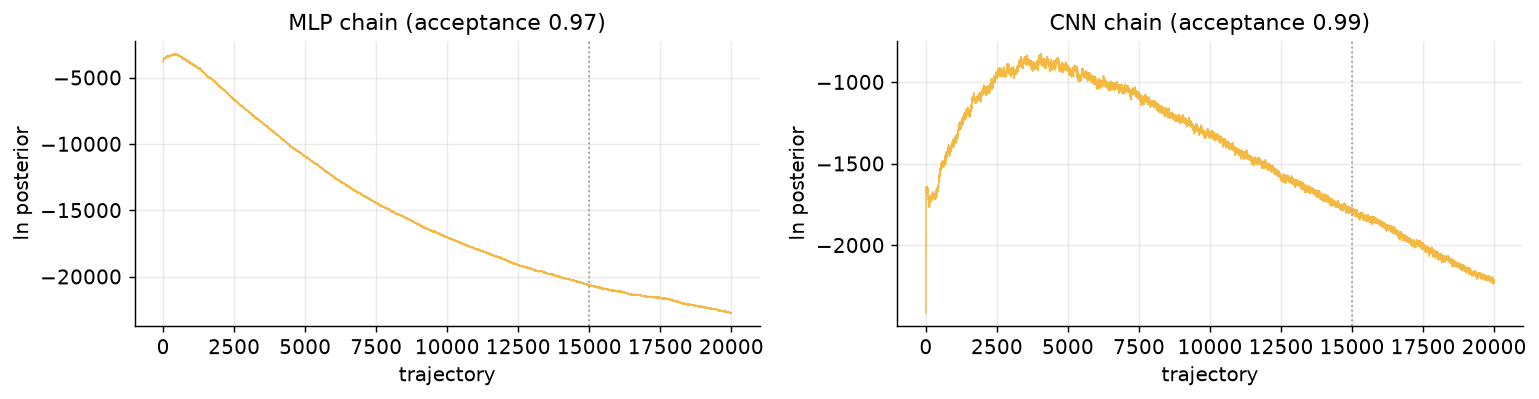

In [9]:
chains = {}
for name in ARCHITECTURES:
    saved = TABLE_DIR / f"exp6_rt_chain_{name}.npz"
    if not saved.exists():
        print(f"[{name}] chain not found at {saved}, run "
              f"experiments/exp6_sample_metropolis.py first")
        continue
    archive = np.load(saved)
    log_posterior_trace = np.asarray(archive["ln_post"])
    n_trajectories = len(log_posterior_trace)

    final_quarter = log_posterior_trace[3 * n_trajectories // 4:]
    slope = np.polyfit(np.arange(len(final_quarter)), final_quarter, 1)[0]
    drift = slope * len(final_quarter)     # nats moved across the final quarter
    noise = final_quarter.std()
    stationary = abs(drift) < 2 * noise
    if stationary:
        # first entry into the stationary band, valid whether the chain
        # approaches from below (a climb) or from above (a descent)
        in_band = np.abs(log_posterior_trace - final_quarter.mean()) <= 2 * noise
        burn_in = int(np.argmax(in_band))
    else:
        burn_in = 3 * n_trajectories // 4  # analyze the final quarter, flagged below

    acceptance = float(np.mean(np.diff(log_posterior_trace) != 0))
    chains[name] = dict(samples=archive["samples"],
                        log_posterior_trace=log_posterior_trace,
                        burn_in=burn_in,
                        acceptance=acceptance,
                        stationary=stationary,
                        step_size=float(archive["dt"]),
                        trajectory_length=int(archive["L"]),
                        wall_seconds=float(archive["wall_s"]),
                        n_trajectories=n_trajectories)
    status = (f"stationary, burn-in {burn_in}" if stationary else
              f"STILL IN TRANSIT (final-quarter drift {drift:+,.0f} nats "
              f"vs noise {noise:,.0f})")
    print(f"[{name}] {n_trajectories} trajectories, "
          f"dt={chains[name]['step_size']:.1e}, "
          f"L={chains[name]['trajectory_length']}, acceptance={acceptance:.2f}, "
          f"wall={chains[name]['wall_seconds'] / 60:.0f} min -> {status}")

if chains:
    figure, axes = plt.subplots(1, len(chains), figsize=(6 * len(chains), 3.2))
    axes = np.atleast_1d(axes)
    for axis, (name, chain) in zip(axes, chains.items()):
        axis.plot(chain["log_posterior_trace"], color=RT, lw=0.8)
        axis.axvline(chain["burn_in"], color=GREY, ls=":", lw=1)
        axis.set_title(f"{name.upper()} chain "
                       f"(acceptance {chain['acceptance']:.2f})")
        axis.set_xlabel("trajectory")
        axis.set_ylabel("ln posterior")
    plt.tight_layout()
    plt.show()

### What the descent is made of

The log-posterior has two parts, $-\sum_i \mathrm{CE}_i$ and $-\tfrac12\lVert\theta\rVert^2$, and decomposing the trace along the MLP chain shows which one drives the march. The prior's typical shell has $\lVert\theta\rVert^2 \approx D$ (a prior term costing $\approx D/2 = 25{,}445$ nats of log-density), while the Adam checkpoint sits at $\lVert\theta\rVert^2 = 174$, absurdly close to the origin by the prior's standards. The prior is weak in density but mighty in volume. In the table, "prior cost" is the magnitude $\tfrac12\lVert\theta\rVert^2$; the first row is the checkpoint itself and the remaining rows are stored samples along the chain (the first stored sample is already one trajectory past the checkpoint).

How to read the table below: sum CE is the training misfit, lower means a better fit to the training data. ||theta||^2 and prior cost have no better direction; under this prior the chain is expected to drive ||theta||^2 toward the shell value printed under the table. ln post is higher = more probable point, but a correctly sampling chain is expected to drift well below the mode, so a falling ln post is not a failure.

In [10]:
if "mlp" in chains:
    chain = chains["mlp"]
    model = ARCHITECTURES["mlp"]().to(DEVICE)
    _, vector_to_parameter_dict = make_log_posterior(model)

    def decompose(theta):
        """Split -ln posterior into the data misfit (sum CE) and the prior cost."""
        parameters = vector_to_parameter_dict(theta)
        with torch.no_grad():
            misfit = sum(
                F.cross_entropy(
                    torch.func.functional_call(model, parameters, (images,)),
                    labels, reduction="sum").item()
                for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS))
        squared_norm = float((theta ** 2).sum())
        return misfit, squared_norm

    checkpoint_vector = torch.cat(
        [p.detach().flatten()
         for p in point_estimates["mlp"]["model"].parameters()]).to(DEVICE)
    entries = [("checkpoint", checkpoint_vector)]
    for k in np.linspace(0, chain["n_trajectories"] - 1, 5).astype(int):
        sample_vector = torch.tensor(np.asarray(chain["samples"][k]), device=DEVICE)
        entries.append((f"sample {k}", sample_vector))

    print(f"{'state':>12s} {'sum CE':>9s} {'||theta||^2':>12s} "
          f"{'prior cost':>11s} {'ln post':>10s}")
    for label, theta in entries:
        misfit, squared_norm = decompose(theta)
        print(f"{label:>12s} {misfit:9,.0f} {squared_norm:12,.0f} "
              f"{squared_norm / 2:11,.0f} {-(misfit + squared_norm / 2):10,.0f}")
    dimension = chain["samples"].shape[1]
    print(f"\nprior typical shell: ||theta||^2 = D = {dimension:,} "
          f"-> prior cost = {dimension / 2:,.0f}")

       state    sum CE  ||theta||^2  prior cost    ln post
  checkpoint     3,982          174          87     -4,069
    sample 0     3,731          181          90     -3,821
 sample 4999       319       21,208      10,604    -10,923
 sample 9999       200       33,600      16,800    -17,000
sample 14999       177       40,899      20,449    -20,626
sample 19999       158       45,134      22,567    -22,725

prior typical shell: ||theta||^2 = D = 50,890 -> prior cost = 25,445


### Flat prior vs a prior on every weight

Step 2 offered two priors; a second chain settles what the choice does to the dynamics. It targets the flat-prior posterior, $\ln p(\theta \mid \mathcal{D}) = \ln L(\theta) + \text{const}$, from the same starting point at the same tuned settings, so the only difference is the missing $-\tfrac12\lVert\theta\rVert^2$ term.

The decomposition above makes a prediction. Under the $\mathcal{N}(0,1)$ prior the quadratic term is what brakes the walk at the shell $\lVert\theta\rVert^2 \approx D$. With a flat prior nothing brakes it: the weight norm should grow without limit (a saturating network can always increase its likelihood a little by scaling up), and the log-likelihood trace can look perfectly stationary while that happens. An improper posterior has no typical set to arrive at, and a trace that flatlines while the parameters escape to infinity is exactly the failure a stationarity monitor built on the target alone would miss.

How to read the summary below: lower sum CE means a better training fit. For ||theta||^2 there is no better direction, but the two chains should behave differently: the N(0,1) chain should level off near the shell at 50,890 while the flat chain grows without bound, and that unbounded growth is the pathology. The line saying the flat trace LOOKS stationary is the trap being demonstrated, not a success.

flat-prior chain: 20000 trajectories, acceptance=0.97
  ln L trace, final quarter: drift +21 nats vs noise 12 -> LOOKS stationary
  ||theta||^2 by the end:  flat prior   108,797   N(0,1) prior    45,134   shell D = 50,890
  sum CE by the end:       flat prior        55   N(0,1) prior       158


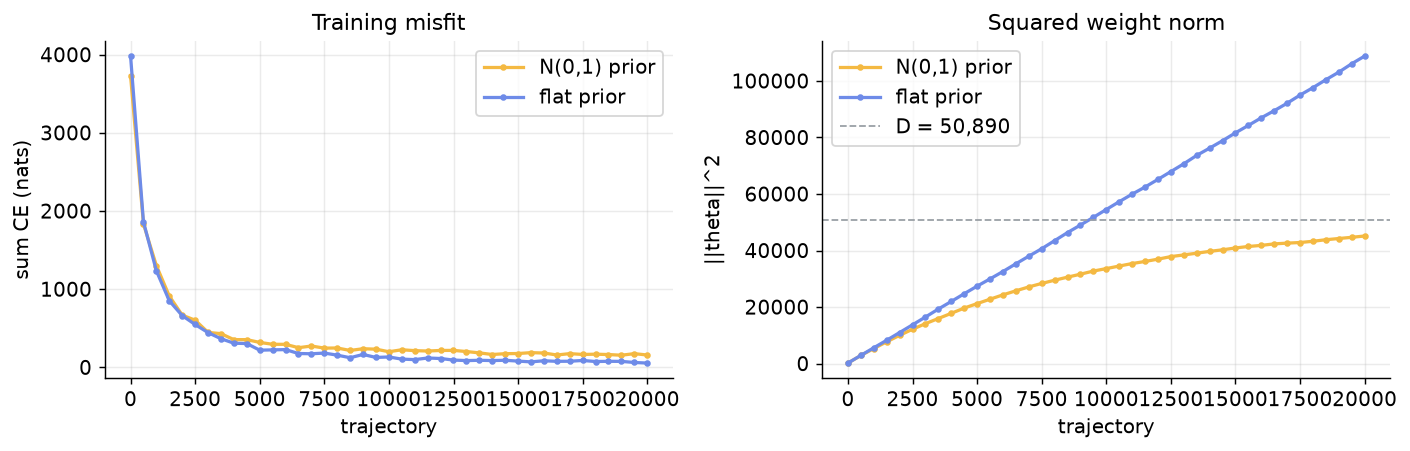

In [11]:
flat_chain_file = TABLE_DIR / "exp6_rt_chain_mlp_flat.npz"
if flat_chain_file.exists() and "mlp" in chains:
    flat_archive = np.load(flat_chain_file)
    flat_samples = flat_archive["samples"]
    flat_trace = np.asarray(flat_archive["ln_post"])     # = ln L, no prior term
    gaussian_chain = chains["mlp"]

    def decomposition_series(samples, n_points=41):
        indices = np.linspace(0, len(samples) - 1, n_points).astype(int)
        misfits, squared_norms = [], []
        for k in indices:
            theta = torch.tensor(np.asarray(samples[k]), device=DEVICE)
            misfit, squared_norm = decompose(theta)
            misfits.append(misfit)
            squared_norms.append(squared_norm)
        return indices, np.array(misfits), np.array(squared_norms)

    gaussian_points, gaussian_misfits, gaussian_norms = decomposition_series(
        gaussian_chain["samples"])
    flat_points, flat_misfits, flat_norms = decomposition_series(flat_samples)
    dimension = flat_samples.shape[1]

    def final_quarter_drift(series):
        quarter = series[3 * len(series) // 4:]
        slope = np.polyfit(np.arange(len(quarter)), quarter, 1)[0]
        return slope * len(quarter), quarter.std()

    trace_drift, trace_noise = final_quarter_drift(flat_trace)
    acceptance_flat = float(np.mean(np.diff(flat_trace) != 0))
    print(f"flat-prior chain: {len(flat_trace)} trajectories, "
          f"acceptance={acceptance_flat:.2f}")
    print(f"  ln L trace, final quarter: drift {trace_drift:+,.0f} nats "
          f"vs noise {trace_noise:,.0f} "
          f"-> {'LOOKS stationary' if abs(trace_drift) < 2 * trace_noise else 'still trending'}")
    print(f"  ||theta||^2 by the end:  flat prior {flat_norms[-1]:>9,.0f}   "
          f"N(0,1) prior {gaussian_norms[-1]:>9,.0f}   shell D = {dimension:,}")
    print(f"  sum CE by the end:       flat prior {flat_misfits[-1]:>9,.0f}   "
          f"N(0,1) prior {gaussian_misfits[-1]:>9,.0f}")

    figure, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))
    left.plot(gaussian_points, gaussian_misfits, color=RT, lw=1.8, marker="o",
              ms=2.6, label="N(0,1) prior")
    left.plot(flat_points, flat_misfits, color=BLUE, lw=1.8, marker="o",
              ms=2.6, label="flat prior")
    left.set_xlabel("trajectory")
    left.set_ylabel("sum CE (nats)")
    left.set_title("Training misfit")
    left.legend()

    right.plot(gaussian_points, gaussian_norms, color=RT, lw=1.8, marker="o",
               ms=2.6, label="N(0,1) prior")
    right.plot(flat_points, flat_norms, color=BLUE, lw=1.8, marker="o",
               ms=2.6, label="flat prior")
    right.axhline(dimension, color=GREY, ls="--", lw=1,
                  label=f"D = {dimension:,}")
    right.set_xlabel("trajectory")
    right.set_ylabel("||theta||^2")
    right.set_title("Squared weight norm")
    right.legend()
    plt.tight_layout()
    plt.show()
else:
    print("flat-prior chain not found; run "
          "experiments/exp6_sample_metropolis.py run mlp 3.5e-4 30 20000 flat")

### A known-answer check

Exactness is a property of the algorithm, so it is decided by auditing preconditions, not by looking at samples. But an audit of the implementation can be backed by a target whose answer is known in closed form. Here the sampler runs on a standard normal in 100 dimensions: every coordinate should have mean 0 and variance 1, and $\lVert\theta\rVert^2$ should concentrate at $D = 100$ with standard deviation $\sqrt{2D} \approx 14$. If the sampler and its accept test are implemented correctly, the moments must come out right; if anything in the kick, the luminosity bookkeeping, or the test were wrong, this is where it would show.

How to read the check below: closer to the theory values is better (mean 0, variance 1, ||theta||^2 near 100 with standard deviation 14). Acceptance just needs to be high; it is not the quantity being validated.

In [12]:
def standard_normal_log_probability(theta):
    return -0.5 * (theta ** 2).sum()

test_dimension = 100
torch.manual_seed(0)
start = torch.zeros(test_dimension, device=DEVICE)
import sys as _sys
_sys.path.insert(0, str(Path.cwd() / "vendor" / "ray-tracing-sampler"))
from raytrace_torch import sample_raytrace

gaussian_samples, gaussian_trace = sample_raytrace(
    start, standard_normal_log_probability, n_steps=2000, n_leapfrog_steps=10,
    step_size=0.1, refresh_rate=0, device=DEVICE, samples_device="cpu",
    scale_likelihood=1.0)
kept = gaussian_samples.numpy()[200:]          # drop a short burn-in
acceptance = float(np.mean(np.diff(gaussian_trace.numpy()) != 0))
squared_norms = (kept ** 2).sum(axis=1)
print(f"acceptance: {acceptance:.2f}")
print(f"coordinate mean:      {kept.mean():+.4f}   (theory 0)")
print(f"coordinate variance:  {kept.var():.4f}   (theory 1)")
print(f"mean ||theta||^2:     {squared_norms.mean():6.1f}   "
      f"(theory {test_dimension}, sd {np.sqrt(2 * test_dimension):.1f})")

Accepted: 99.350000%
acceptance: 0.99
coordinate mean:      -0.0013   (theory 0)
coordinate variance:  1.0045   (theory 1)
mean ||theta||^2:      100.4   (theory 100, sd 14.1)


### Testing the Adam-start axiom: the two jobs of burn-in

Every chain above starts from the trained checkpoint, an assumption worth testing rather than trusting. Burn-in has two jobs: fit the data, and walk to where the prior puts the posterior's mass. The trained start pre-pays the first job; does that actually matter? Two more chains, same target and the same 20,000-trajectory budget, from (a) a fresh random initialization (chance-level fit, tiny norm) and (b) a draw from the N(0,1) prior (norm already on the shell, but a saturated network that is confidently wrong: 17.3 million nats of misfit). Each start got its own step-size pilot, because acceptance is state dependent and the Adam-tuned step accepts nothing at either new start: the random init needed a 12x smaller step, the prior draw 350x smaller before anything moved at all.

How to read the figure below: left panel is the fit job (misfit, lower is better, log scale; the reference chain's final 158 is the floor shown), right panel is the walk job (||theta||^2, no better direction, arrival means leveling near the shell). A chain that finished burn-in would have its left curve at the floor and its right curve at the shell.

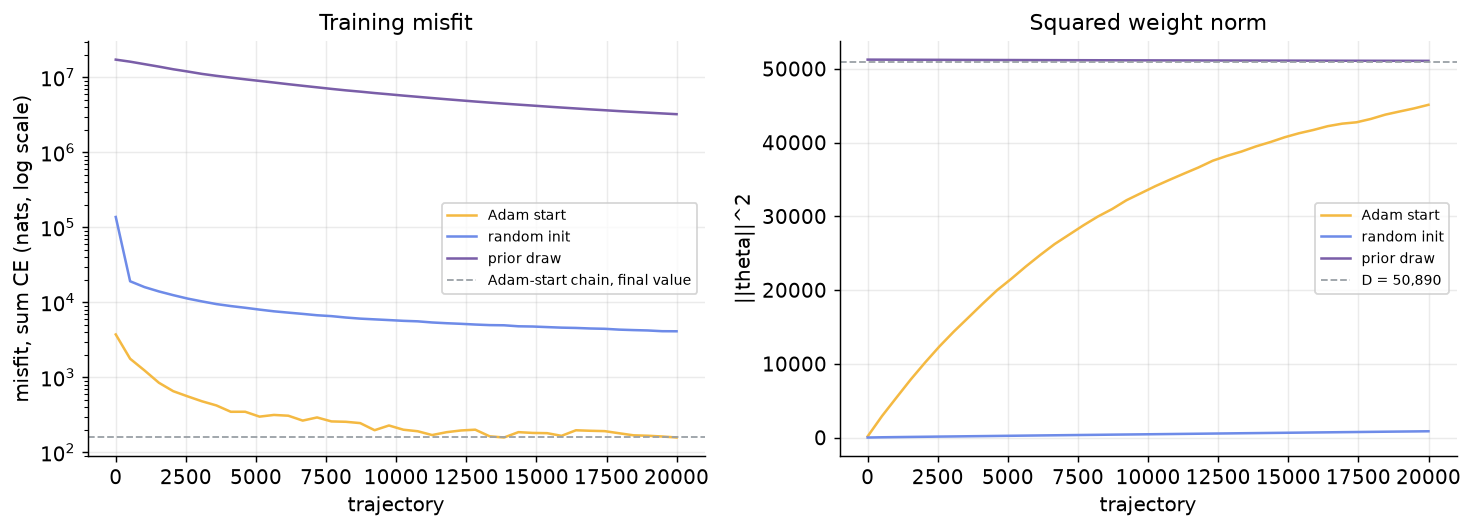

       start  tuned dt  final misfit  final ||theta||^2
  Adam start   3.5e-04           158             45,134
 random init   3.0e-05         4,114                872
  prior draw   1.0e-06     3,233,476             51,094


In [13]:
start_comparison = [
    ("Adam start", TABLE_DIR / "exp6_rt_chain_mlp.npz", RT),
    ("random init", TABLE_DIR / "exp6_rt_chain_mlp_randominit.npz", BLUE),
    ("prior draw", TABLE_DIR / "exp6_rt_chain_mlp_priordraw.npz", "#7A5EA8"),
]
if all(path.exists() for _, path, _ in start_comparison):
    comparison_model = ARCHITECTURES["mlp"]().to(DEVICE)
    _, comparison_unflatten = make_log_posterior(comparison_model)

    def decompose_vector(theta):
        parameters = comparison_unflatten(theta)
        with torch.no_grad():
            misfit = sum(
                F.cross_entropy(
                    torch.func.functional_call(comparison_model, parameters,
                                               (images,)),
                    labels, reduction="sum").item()
                for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS))
        return misfit, float((theta ** 2).sum())

    figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    summary = []
    for label, path, color in start_comparison:
        archive = np.load(path, mmap_mode="r")
        n_stored = archive["samples"].shape[0]
        rows = np.linspace(0, n_stored - 1, 40).astype(int)
        misfit_curve, norm_curve = [], []
        for row in rows:
            theta = torch.tensor(np.asarray(archive["samples"][row]),
                                 device=DEVICE)
            misfit_value, norm_value = decompose_vector(theta)
            misfit_curve.append(misfit_value)
            norm_curve.append(norm_value)
        axes[0].semilogy(rows, misfit_curve, color=color, lw=1.4, label=label)
        axes[1].plot(rows, norm_curve, color=color, lw=1.4, label=label)
        summary.append((label, float(archive["dt"]),
                        misfit_curve[-1], norm_curve[-1]))
    axes[0].axhline(158, color=GREY, ls="--", lw=1,
                    label="Adam-start chain, final value")
    axes[0].set_xlabel("trajectory")
    axes[0].set_ylabel("misfit, sum CE (nats, log scale)")
    axes[0].set_title("Training misfit")
    axes[0].legend(fontsize=8)
    axes[1].axhline(50890, color=GREY, ls="--", lw=1, label="D = 50,890")
    axes[1].set_xlabel("trajectory")
    axes[1].set_ylabel("||theta||^2")
    axes[1].set_title("Squared weight norm")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"{'start':>12} {'tuned dt':>9} {'final misfit':>13} "
          f"{'final ||theta||^2':>18}")
    for label, step_size, final_misfit, final_norm in summary:
        print(f"{label:>12} {step_size:>9.1e} {final_misfit:>13,.0f} "
              f"{final_norm:>18,.0f}")
else:
    print("start-comparison chains not found; run "
          "experiments/exp6_sample_metropolis.py axiom first")

## Step 5: ESS and uncertainty, sampler vs ensemble

Two questions. First, how many independent samples did the chain actually produce? The integrated autocorrelation time $\tau$ (Sokal's windowed estimator) on the log-posterior trace and on a set of 50 random weight coordinates gives $\mathrm{ESS} = n_{\text{post burn}} / \tau$, and dividing by gradient evaluations gives the honest cost.

Second, is the posterior predictive any good? Fifty thinned post-burn-in samples give a posterior predictive to set against the 10-seed deep ensemble and the point estimate: accuracy, NLL, expected calibration error, and per-image spread.

How to read the numbers below: tau, lower is better (the chain decorrelates faster); ESS and ESS per 1k gradient evaluations, higher is better. In the predictive table: accuracy higher is better, NLL and ECE lower is better, and median spread has no better direction, it is how much uncertainty each method expresses (0 means the members agree exactly). One more thing to expect in the spread histograms: the RT distribution for the MLP is bimodal. On roughly 90% of images every sample agrees with full certainty (spread exactly 0), and on roughly 8% the samples disagree completely (spread near 0.5), with almost nothing in between. That all-or-nothing shape is the signature of saturated networks from the late chain, not a graded uncertainty like the ensemble's.

In [14]:
for name, chain in chains.items():
    trace = chain["log_posterior_trace"][chain["burn_in"]:]
    window = len(trace)
    tau_of_trace, _ = tau_sokal(trace)

    generator = np.random.default_rng(0)
    coordinate_indices = generator.choice(chain["samples"].shape[1], size=50,
                                          replace=False)
    coordinates = np.asarray(chain["samples"][chain["burn_in"]:,
                                              coordinate_indices],
                             dtype=np.float64)
    coordinate_taus = [tau_sokal(coordinates[:, j])[0]
                       for j in range(coordinates.shape[1])]

    # autograd calls only; each trajectory adds 2 forward-only evaluations
    gradient_evaluations = chain["n_trajectories"] * chain["trajectory_length"]
    ess_of_trace = window / tau_of_trace
    ess_of_coordinates = window / np.median(coordinate_taus)

    notes = [] if chain["stationary"] else ["chain in transit: optimistic"]
    if window < 50 * tau_of_trace:
        notes.append(f"window is only {window / tau_of_trace:.0f} tau, well under "
                     "the 50 tau rule: tau underestimated, ESS an upper bound")
    note = ("   [" + "; ".join(notes) + "]") if notes else ""
    print(f"[{name}] analyzed window n={window}{note}")
    print(f"  tau(ln post) ~ {tau_of_trace:5.0f}  -> ESS {ess_of_trace:6.1f}")
    print(f"  tau(coords) median ~ {np.median(coordinate_taus):5.0f}"
          f"  -> ESS {ess_of_coordinates:6.1f}"
          f"  (worst {window / np.max(coordinate_taus):5.1f})")
    print(f"  {gradient_evaluations:,} gradient evals "
          f"(+{2 * chain['n_trajectories']:,} forward evals), "
          f"{chain['wall_seconds'] / 60:.0f} min "
          f"-> {1000 * ess_of_coordinates / gradient_evaluations:.2f} "
          f"ESS per 1k gradient evals")

[mlp] analyzed window n=5000   [chain in transit: optimistic; window is only 7 tau, well under the 50 tau rule: tau underestimated, ESS an upper bound]
  tau(ln post) ~   732  -> ESS    6.8
  tau(coords) median ~   569  -> ESS    8.8  (worst   6.9)
  600,000 gradient evals (+40,000 forward evals), 51 min -> 0.01 ESS per 1k gradient evals
[cnn] analyzed window n=5000   [chain in transit: optimistic; window is only 7 tau, well under the 50 tau rule: tau underestimated, ESS an upper bound]
  tau(ln post) ~   724  -> ESS    6.9
  tau(coords) median ~   554  -> ESS    9.0  (worst   7.1)
  600,000 gradient evals (+40,000 forward evals), 0 min -> 0.02 ESS per 1k gradient evals


In [15]:
PREDICTIVE_SAMPLES = 50


def posterior_predictive(name, samples, start, stop):
    """Test-set probabilities from PREDICTIVE_SAMPLES chain samples thinned
    evenly over trajectories [start, stop)."""
    model = ARCHITECTURES[name]().to(DEVICE)
    _, vector_to_parameter_dict = make_log_posterior(model)
    member_probabilities = []
    for k in np.linspace(start, stop - 1, PREDICTIVE_SAMPLES).astype(int):
        theta = torch.tensor(np.asarray(samples[k]), device=DEVICE)
        parameters = vector_to_parameter_dict(theta)
        with torch.no_grad():
            batches = [F.softmax(torch.func.functional_call(
                           model, parameters, (images.to(DEVICE),)), dim=1)
                       .cpu().numpy()
                       for images, _ in test_loader]
        member_probabilities.append(np.concatenate(batches))
    return np.stack(member_probabilities)


rows = []
for name in chains:
    labels = point_estimates[name]["labels"]
    chain = chains[name]
    final_quarter_predictive = posterior_predictive(
        name, chain["samples"], chain["burn_in"], chain["n_trajectories"])
    variants = [("point", point_estimates[name]["probabilities"][None]),
                (f"ensemble ({ENSEMBLE_SIZE})",
                 ensembles[name]["member_probabilities"]),
                (f"MC dropout ({MC_DROPOUT_PASSES})",
                 mc_dropout[name]["member_probabilities"]),
                ("RT chain, final quarter", final_quarter_predictive)]
    # an early window of the SAME chain shows what a not-yet-converged chain
    # would have reported if stopped there
    if not chain["stationary"] and chain["n_trajectories"] >= 4000:
        variants.append(("RT chain, first 2k traj",
                         posterior_predictive(name, chain["samples"], 0, 2000)))
    if name == "mlp" and (TABLE_DIR / "exp6_rt_chain_mlp_flat.npz").exists():
        flat_samples_for_predictive = np.load(
            TABLE_DIR / "exp6_rt_chain_mlp_flat.npz")["samples"]
        n_flat = len(flat_samples_for_predictive)
        variants.append(("RT chain, flat prior",
                         posterior_predictive(name, flat_samples_for_predictive,
                                              3 * n_flat // 4, n_flat)))
    eq33_base = TABLE_DIR / "exp6_mb33_dt0.0001_rr5.npz"
    eq33_parts = sorted(TABLE_DIR.glob("exp6_mb33_dt0.0001_rr5_part*.npz"),
                        key=lambda path: int(path.stem.rsplit("part", 1)[1]))
    if name == "mlp" and eq33_parts:
        # the converged minibatch chain: 50 members thinned over the final
        # quarter of the combined snapshot series (base arm + all legs)
        eq33_files = [eq33_base] + eq33_parts
        snapshot_counts = [len(np.load(path)["steps"]) for path in eq33_files]
        snapshot_offsets = np.cumsum([0] + snapshot_counts)
        total_snapshots = snapshot_offsets[-1]
        wanted = np.linspace(3 * total_snapshots // 4, total_snapshots - 1,
                             PREDICTIVE_SAMPLES).astype(int)
        rows_by_file = {}
        for snapshot_index in wanted:
            file_index = int(np.searchsorted(snapshot_offsets, snapshot_index,
                                             side="right") - 1)
            rows_by_file.setdefault(file_index, []).append(
                int(snapshot_index - snapshot_offsets[file_index]))
        eq33_members = []
        for file_index in sorted(rows_by_file):
            snapshots = np.load(eq33_files[file_index])["snapshots"]
            eq33_members.extend(snapshots[row]
                                for row in rows_by_file[file_index])
        variants.append(("RT minibatch Eq. 33, converged",
                         posterior_predictive(name, np.stack(eq33_members),
                                              0, PREDICTIVE_SAMPLES)))
    cnn_eq33_base = TABLE_DIR / "exp6_mb33_cnn_dt0.0001_rr5.npz"
    cnn_eq33_parts = sorted(
        TABLE_DIR.glob("exp6_mb33_cnn_dt0.0001_rr5_part*.npz"),
        key=lambda path: int(path.stem.rsplit("part", 1)[1]))
    if name == "cnn" and cnn_eq33_parts:
        cnn_files = [cnn_eq33_base] + cnn_eq33_parts
        cnn_counts = [len(np.load(path)["steps"]) for path in cnn_files]
        cnn_offsets = np.cumsum([0] + cnn_counts)
        cnn_total = cnn_offsets[-1]
        cnn_wanted = np.linspace(3 * cnn_total // 4, cnn_total - 1,
                                 PREDICTIVE_SAMPLES).astype(int)
        cnn_rows = {}
        for snapshot_index in cnn_wanted:
            file_index = int(np.searchsorted(cnn_offsets, snapshot_index,
                                             side="right") - 1)
            cnn_rows.setdefault(file_index, []).append(
                int(snapshot_index - cnn_offsets[file_index]))
        cnn_members = []
        for file_index in sorted(cnn_rows):
            snapshots = np.load(cnn_files[file_index])["snapshots"]
            cnn_members.extend(snapshots[row] for row in cnn_rows[file_index])
        variants.append(("RT minibatch Eq. 33, converged",
                         posterior_predictive(name, np.stack(cnn_members),
                                              0, PREDICTIVE_SAMPLES)))

    for label, probabilities in variants:
        mean = probabilities.mean(axis=0)
        accuracy = (mean.argmax(axis=1) == labels).mean()
        negative_log_likelihood = -np.log(
            mean[np.arange(len(labels)), labels] + 1e-12).mean()
        median_spread = (np.median(probabilities.std(axis=0).max(axis=1))
                         if len(probabilities) > 1 else 0.0)
        rows.append((name, label, accuracy, negative_log_likelihood,
                     expected_calibration_error(mean, labels), median_spread))
    chain["predictive_probabilities"] = final_quarter_predictive

print(f"{'model':6s} {'predictive':>24s} {'acc':>7s} {'NLL':>7s} {'ECE':>7s} "
      f"{'med spread':>11s}")
for row in rows:
    print(f"{row[0]:6s} {row[1]:>24s} {row[2]:7.4f} {row[3]:7.4f} "
          f"{row[4]:7.4f} {row[5]:11.5f}")

model                predictive     acc     NLL     ECE  med spread
mlp                       point  0.9734  0.0928  0.0048     0.00000
mlp               ensemble (10)  0.9775  0.0787  0.0149     0.00256
mlp             MC dropout (50)  0.9669  0.1223  0.0283     0.03223
mlp     RT chain, final quarter  0.9689  0.2651  0.0140     0.00000
mlp     RT chain, first 2k traj  0.9738  0.0866  0.0045     0.00034
mlp        RT chain, flat prior  0.9668  0.3687  0.0199     0.00000
mlp    RT minibatch Eq. 33, converged  0.9744  0.1576  0.0057     0.00000
cnn                       point  0.9847  0.0474  0.0020     0.00000
cnn               ensemble (10)  0.9904  0.0310  0.0071     0.00040
cnn             MC dropout (50)  0.9881  0.0343  0.0061     0.00057
cnn     RT chain, final quarter  0.9875  0.1308  0.0069     0.00000
cnn     RT chain, first 2k traj  0.9888  0.0337  0.0022     0.00007
cnn    RT minibatch Eq. 33, converged  0.9892  0.0854  0.0033     0.00000


Who wins the table above depends on the contest. For pure prediction the deep ensemble wins outright (best accuracy and NLL, at the cost of ten training runs), and the point estimate is hard to beat: against the converged chain it is a split decision, the chain edges accuracy while the point keeps a clearly better NLL and slightly better calibration. What the converged chains win is a different contest: the two Eq. 33 rows are the only ones that come from an actual converged posterior. Every other sampled row is a transient, and converging mattered, the equilibrium posterior scores NLL 0.158 where the same chain's in-transit window scored 0.265. So the true posterior is better than the transient made it look, and the gap that remains against the point estimate is a property of the T=1 posterior itself, not an artifact of stopping early.

### Is the converged posterior's uncertainty useful?

The spread histograms showed the converged chain's disagreement is all or nothing. This cell asks whether that blunt signal still does the one job uncertainty is for, telling you which predictions not to trust, and puts every method on the same footing: each flags its own most-uncertain images at the same review budget (the size of the chain's spread > 0.05 set) and is judged on its own test errors. The point estimate competes with the classic signal, its own softmax confidence. How to read the table: recall (errors caught), higher is better; enrichment compares the error rate inside the flagged set to outside it, higher is better.

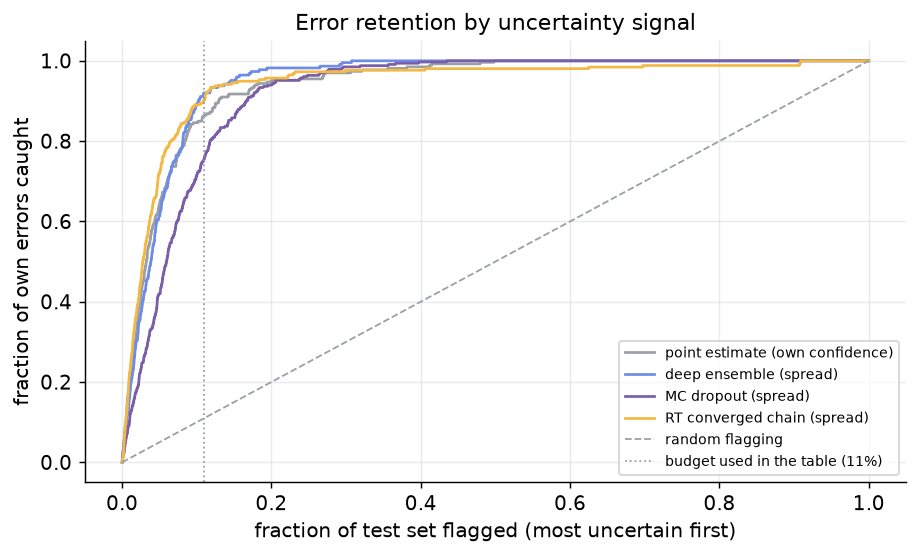

review budget: 1,098 flagged images (11% of the test set)

                          method own errors  caught  recall  enrichment
 point estimate (own confidence)        266     230     86%         52x
          deep ensemble (spread)        225     207     92%         93x
             MC dropout (spread)        331     250     76%         25x
     RT converged chain (spread)        256     231     90%         75x


In [16]:
if "eq33_members" in dir():
    converged_probabilities = posterior_predictive(
        "mlp", np.stack(eq33_members), 0, PREDICTIVE_SAMPLES)
    test_labels = point_estimates["mlp"]["labels"]
    chain_spread = converged_probabilities.std(axis=0).max(axis=1)
    review_budget = int((chain_spread > 0.05).sum())

    def flag_score(method, probabilities, uncertainty):
        """Flag the review_budget most-uncertain images by this method's own
        signal; score against this method's own errors."""
        predicted = probabilities.argmax(axis=1)
        wrong = predicted != test_labels
        flagged = np.zeros(len(test_labels), dtype=bool)
        flagged[np.argsort(-uncertainty)[:review_budget]] = True
        caught = int((wrong & flagged).sum())
        inside = caught / review_budget
        outside = (wrong.sum() - caught) / (len(test_labels) - review_budget)
        return (method, int(wrong.sum()), caught,
                100 * caught / wrong.sum(), inside / outside)

    point_probabilities = point_estimates["mlp"]["probabilities"]
    ensemble_members = ensembles["mlp"]["member_probabilities"]
    dropout_members = mc_dropout["mlp"]["member_probabilities"]
    scores = [
        flag_score("point estimate (own confidence)", point_probabilities,
                   1.0 - point_probabilities.max(axis=1)),
        flag_score("deep ensemble (spread)", ensemble_members.mean(axis=0),
                   ensemble_members.std(axis=0).max(axis=1)),
        flag_score("MC dropout (spread)", dropout_members.mean(axis=0),
                   dropout_members.std(axis=0).max(axis=1)),
        flag_score("RT converged chain (spread)",
                   converged_probabilities.mean(axis=0), chain_spread),
    ]
    method_styles = [
        ("point estimate (own confidence)", point_probabilities,
         1.0 - point_probabilities.max(axis=1), GREY),
        ("deep ensemble (spread)", ensemble_members.mean(axis=0),
         ensemble_members.std(axis=0).max(axis=1), BLUE),
        ("MC dropout (spread)", dropout_members.mean(axis=0),
         dropout_members.std(axis=0).max(axis=1), "#7A5EA8"),
        ("RT converged chain (spread)", converged_probabilities.mean(axis=0),
         chain_spread, RT),
    ]
    figure, axis = plt.subplots(figsize=(7.2, 4.4))
    n_images = len(test_labels)
    for method, probabilities, uncertainty, color in method_styles:
        wrong = probabilities.argmax(axis=1) != test_labels
        order = np.argsort(-uncertainty)
        caught_curve = np.cumsum(wrong[order]) / wrong.sum()
        axis.plot(np.arange(1, n_images + 1) / n_images, caught_curve,
                  color=color, lw=1.5, label=method)
    axis.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1,
              label="random flagging")
    axis.axvline(review_budget / n_images, color=GREY, ls=":", lw=1,
                 label=f"budget used in the table "
                       f"({review_budget / n_images:.0%})")
    axis.set_xlabel("fraction of test set flagged (most uncertain first)")
    axis.set_ylabel("fraction of own errors caught")
    axis.set_title("Error retention by uncertainty signal")
    axis.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()

    print(f"review budget: {review_budget:,} flagged images "
          f"({review_budget / len(test_labels):.0%} of the test set)\n")
    print(f"{'method':>32} {'own errors':>10} {'caught':>7} "
          f"{'recall':>7} {'enrichment':>11}")
    for method, wrong, caught, recall, enrichment in scores:
        print(f"{method:>32} {wrong:>10} {caught:>7} {recall:>6.0f}% "
              f"{enrichment:>10.0f}x")
else:
    print("run the predictive cell above first (needs eq33_members)")

### More comparisons: calibration, sample efficiency, and agreement

Three further cuts through the same objects. The reliability diagram shows where each method's confidence matches its accuracy (closer to the diagonal is better; below the diagonal means overconfident). The scaling figure asks what each additional member buys (lower NLL is better; a curve that flattens early means members are redundant). The overlap table asks whether the methods even flag the same images (Jaccard of 1 means identical flagged sets at the shared budget).

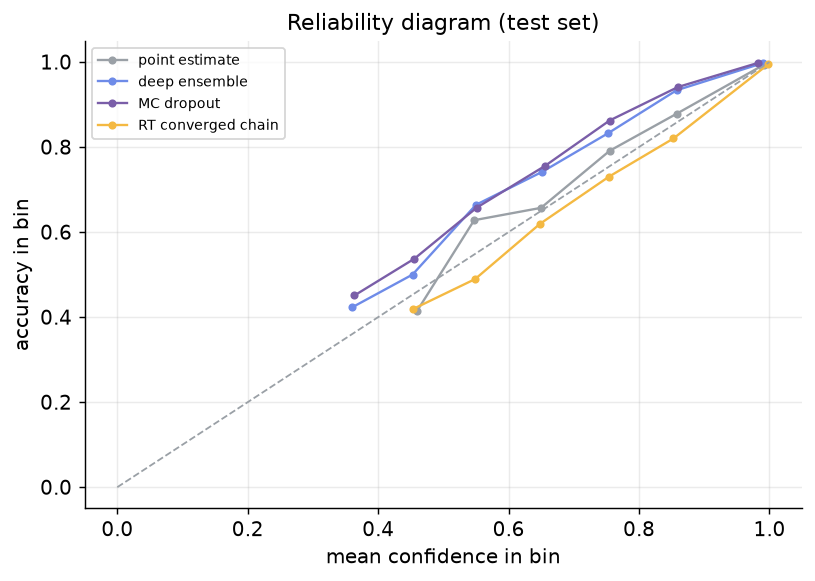

In [17]:
if "converged_probabilities" in dir():
    reliability_methods = [
        ("point estimate", point_probabilities, GREY),
        ("deep ensemble", ensemble_members.mean(axis=0), BLUE),
        ("MC dropout", dropout_members.mean(axis=0), "#7A5EA8"),
        ("RT converged chain", converged_probabilities.mean(axis=0), RT),
    ]
    bin_edges = np.linspace(0.1, 1.0, 10)
    figure, axis = plt.subplots(figsize=(6.4, 4.6))
    for name, probabilities, color in reliability_methods:
        confidence = probabilities.max(axis=1)
        correct = probabilities.argmax(axis=1) == test_labels
        mean_confidence, accuracy = [], []
        for low, high in zip(bin_edges[:-1], bin_edges[1:]):
            mask = (confidence >= low) & (confidence <= high)
            if mask.sum() >= 20:   # skip bins too small to estimate
                mean_confidence.append(confidence[mask].mean())
                accuracy.append(correct[mask].mean())
        axis.plot(mean_confidence, accuracy, marker="o", ms=3.5, lw=1.3,
                  color=color, label=name)
    axis.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1)
    axis.set_xlabel("mean confidence in bin")
    axis.set_ylabel("accuracy in bin")
    axis.set_title("Reliability diagram (test set)")
    axis.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()

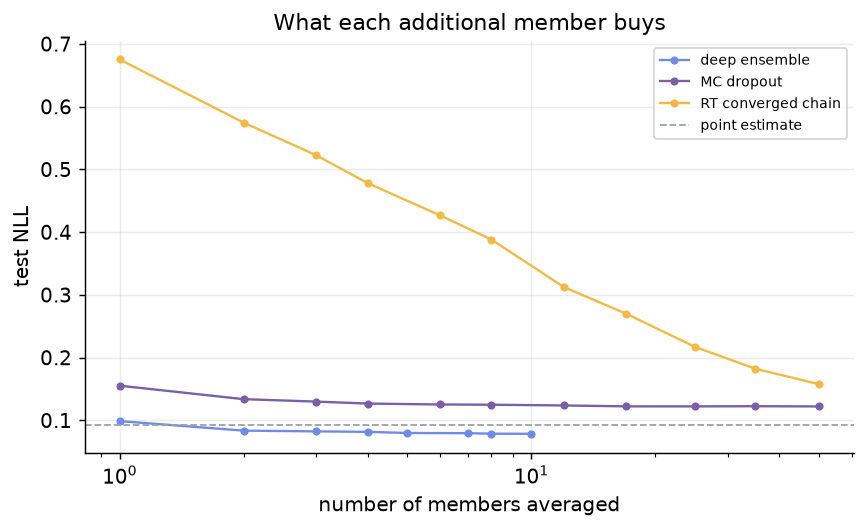

In [18]:
if "converged_probabilities" in dir():
    def negative_log_likelihood(mean_probabilities):
        true_class = mean_probabilities[np.arange(len(test_labels)),
                                        test_labels]
        return float(-np.log(np.clip(true_class, 1e-12, None)).mean())

    scaling_methods = [
        ("deep ensemble", ensemble_members, BLUE),
        ("MC dropout", dropout_members, "#7A5EA8"),
        ("RT converged chain", converged_probabilities, RT),
    ]
    figure, axis = plt.subplots(figsize=(6.8, 4.2))
    for name, member_array, color in scaling_methods:
        counts = np.unique(np.round(np.logspace(
            0, np.log10(member_array.shape[0]), 12)).astype(int))
        axis.plot(counts,
                  [negative_log_likelihood(member_array[:k].mean(axis=0))
                   for k in counts],
                  marker="o", ms=3.5, lw=1.3, color=color, label=name)
    axis.axhline(negative_log_likelihood(point_probabilities), color=GREY,
                 ls="--", lw=1, label="point estimate")
    axis.set_xscale("log")
    axis.set_xlabel("number of members averaged")
    axis.set_ylabel("test NLL")
    axis.set_title("What each additional member buys")
    axis.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [19]:
if "converged_probabilities" in dir():
    uncertainty_signals = {
        "point": 1.0 - point_probabilities.max(axis=1),
        "ensemble": ensemble_members.std(axis=0).max(axis=1),
        "dropout": dropout_members.std(axis=0).max(axis=1),
        "chain": chain_spread,
    }
    flagged_sets = {name: set(np.argsort(-signal)[:review_budget])
                    for name, signal in uncertainty_signals.items()}
    names = list(flagged_sets)
    print("Jaccard overlap of the flagged sets (shared budget of "
          f"{review_budget:,} images):")
    print(f"{'':>10}" + "".join(f"{n:>10}" for n in names))
    for a in names:
        row = "".join(
            f"{len(flagged_sets[a] & flagged_sets[b]) / len(flagged_sets[a] | flagged_sets[b]):>10.2f}"
            for b in names)
        print(f"{a:>10}" + row)
    print("\nthe methods only half-agree on which images are hard: each "
          "signal carries some information the others miss")

Jaccard overlap of the flagged sets (shared budget of 1,098 images):
               point  ensemble   dropout     chain
     point      1.00      0.52      0.38      0.40
  ensemble      0.52      1.00      0.46      0.44
   dropout      0.38      0.46      1.00      0.32
     chain      0.40      0.44      0.32      1.00

the methods only half-agree on which images are hard: each signal carries some information the others miss


### Fake images: who stays confident on garbage

The comparisons above all score the methods on real digits. This one shows them images that are not digits at all, 10,000 each of gaussian noise, Fashion-MNIST (real structure, wrong domain), and polarity-inverted MNIST, and asks two things. First, does the method's confidence collapse the way it should (median top-class confidence, lower is better on fakes; on real test images every method sits near 1.0)? Second, does its uncertainty signal flag the fakes, using the same threshold that flags 11% of the real test set (higher is better; AUROC is threshold-free, 0.5 is blind and 1.0 is perfect)? The numbers are produced by `experiments/exp6_fake_images.py`, which rebuilds the ensemble members from their original seeds, and loaded here from its saved artifact.

    method         fake set  median conf  flagged  AUROC
     point   gaussian noise        0.436    100%   0.99
     point    Fashion-MNIST        0.785     72%   0.86
     point   inverted MNIST        0.805     75%   0.91
  ensemble   gaussian noise        0.374     98%   0.94
  ensemble    Fashion-MNIST        0.612     79%   0.90
  ensemble   inverted MNIST        0.342    100%   1.00
   dropout   gaussian noise        0.457     47%   0.88
   dropout    Fashion-MNIST        0.635     62%   0.88
   dropout   inverted MNIST        0.692     88%   0.95
     chain   gaussian noise        0.557     98%   0.98
     chain    Fashion-MNIST        0.673     88%   0.93
     chain   inverted MNIST        0.640     93%   0.94


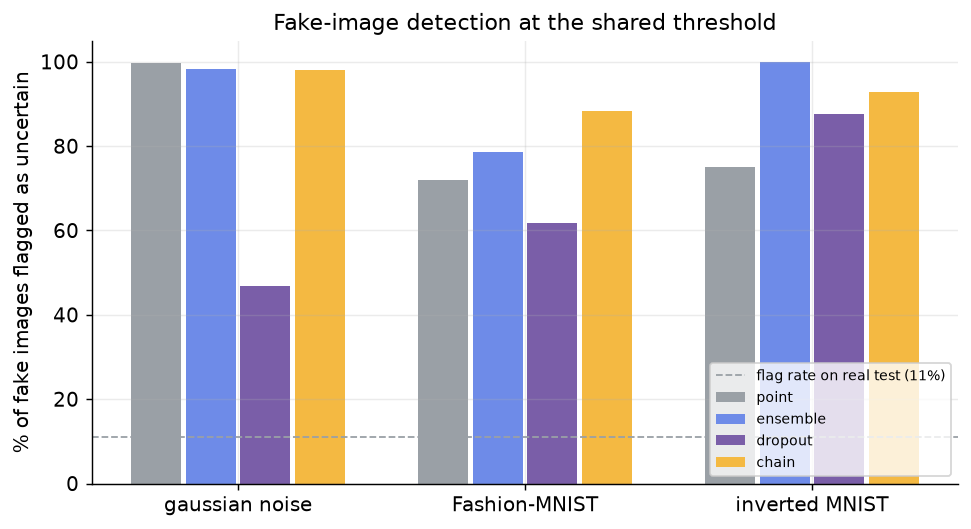

In [20]:
fake_results_file = TABLE_DIR / "exp6_fake_images.npz"
if fake_results_file.exists():
    fake_archive = np.load(fake_results_file)
    fake_methods = [str(m) for m in fake_archive["methods"]]
    fake_sets = [str(s) for s in fake_archive["sets"]]
    flag_rates = fake_archive["flag_rates"]
    aurocs = fake_archive["aurocs"]
    fake_medians = fake_archive["medians"]

    print(f"{'method':>10} {'fake set':>16} {'median conf':>12} "
          f"{'flagged':>8} {'AUROC':>6}")
    for i, method in enumerate(fake_methods):
        for j, set_name in enumerate(fake_sets):
            print(f"{method:>10} {set_name:>16} {fake_medians[i, j]:>12.3f} "
                  f"{flag_rates[i, j]:>7.0%} {aurocs[i, j]:>6.2f}")

    method_colors = {"point": GREY, "ensemble": BLUE,
                     "dropout": "#7A5EA8", "chain": RT}
    positions = np.arange(len(fake_sets))
    width = 0.19
    figure, axis = plt.subplots(figsize=(7.6, 4.2))
    for i, method in enumerate(fake_methods):
        axis.bar(positions + (i - 1.5) * width, 100 * flag_rates[i],
                 width * 0.92, color=method_colors[method], label=method)
    axis.axhline(11, color=GREY, ls="--", lw=1,
                 label="flag rate on real test (11%)")
    axis.set_xticks(positions)
    axis.set_xticklabels(fake_sets)
    axis.set_ylabel("% of fake images flagged as uncertain")
    axis.set_title("Fake-image detection at the shared threshold")
    axis.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("run experiments/exp6_fake_images.py first")

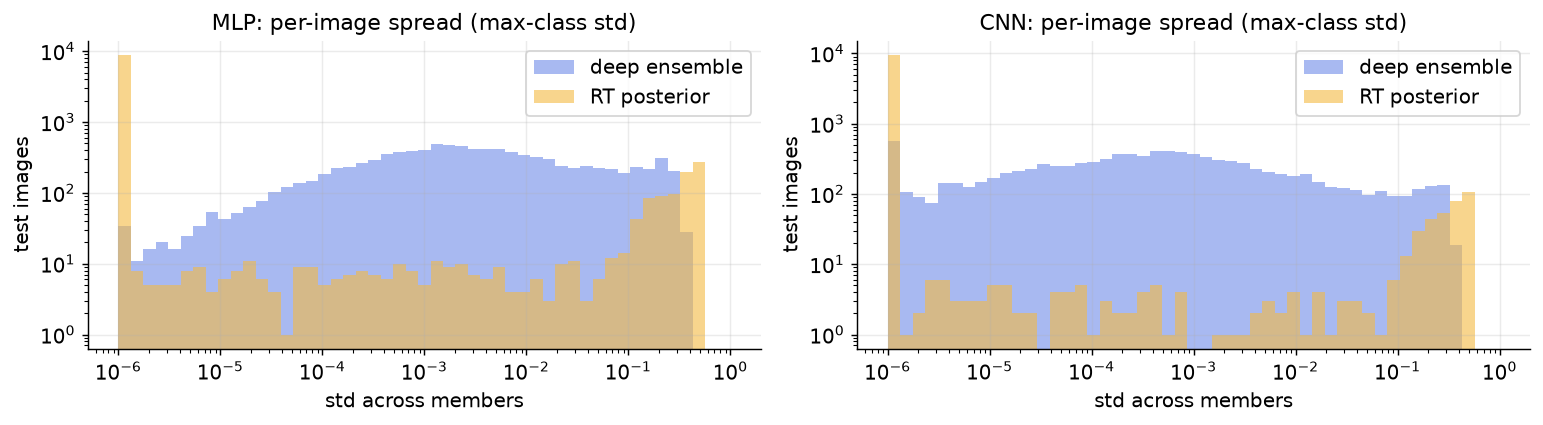

In [21]:
if chains:
    figure, axes = plt.subplots(1, len(chains), figsize=(6 * len(chains), 3.4))
    axes = np.atleast_1d(axes)
    for axis, name in zip(axes, chains):
        chain_spread = (chains[name]["predictive_probabilities"]
                        .std(axis=0).max(axis=1))
        ensemble_spread = (ensembles[name]["member_probabilities"]
                           .std(axis=0).max(axis=1))
        bins = np.logspace(-6, 0, 50)
        # clip zero spreads INTO the first bin (a bare 1e-6 lands a float
        # hair below bins[0] and np.histogram silently drops those images)
        axis.hist(np.clip(ensemble_spread, bins[0], None), bins=bins, alpha=0.6,
                  color=BLUE, label="deep ensemble")
        axis.hist(np.clip(chain_spread, bins[0], None), bins=bins, alpha=0.6,
                  color=RT, label="RT posterior")
        axis.set_xscale("log")
        axis.set_yscale("log")  # the zero-spread bar dwarfs everything else
        axis.set_title(f"{name.upper()}: per-image spread (max-class std)")
        axis.set_xlabel("std across members")
        axis.set_ylabel("test images")
        axis.legend()
    plt.tight_layout()
    plt.show()

## The minibatch regime: keep the noise, drop the test

Everything above ran full batch so the Metropolis test could be exact. The sampler's actual selling point is the opposite regime: one minibatch per step, where its constant speed means a noisy gradient can only steer the ray, never heat it. The casualty is the accept test, and this chapter measures every side of that trade on the MLP posterior, with the exact chain above as ground truth.

First, why the test cannot simply run on batches. The accept decision thresholds on $\Delta \ln p(\theta \mid \mathcal{D})$ between two states. The cell below takes one real accepted trajectory from the exact chain and measures what a batch-256 estimate of its $\Delta \ln L$ looks like.

How to read the measurement below: a usable estimate would need a std far below the true change and a wrong-sign fraction near 0%. A wrong-sign fraction near 50% is a coin flip, meaning the estimate carries almost no information about the true change.

In [22]:
trajectory_index = 1000
chain = chains["mlp"]
theta_start = torch.tensor(np.asarray(chain["samples"][trajectory_index]),
                           device=DEVICE)
theta_end = torch.tensor(np.asarray(chain["samples"][trajectory_index + 1]),
                         device=DEVICE)
model = ARCHITECTURES["mlp"]().to(DEVICE)
_, vector_to_parameter_dict = make_log_posterior(model)

def per_image_cross_entropy(theta):
    parameters = vector_to_parameter_dict(theta)
    with torch.no_grad():
        batches = [F.cross_entropy(
                       torch.func.functional_call(model, parameters, (images,)),
                       labels, reduction="none")
                   for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS)]
    return torch.cat(batches)

contribution = (per_image_cross_entropy(theta_start)
                - per_image_cross_entropy(theta_end))
true_delta_log_likelihood = float(contribution.sum())

generator = np.random.default_rng(0)
estimates = []
for _ in range(500):
    batch = torch.tensor(generator.choice(TRAINING_SET_SIZE, 256, replace=False),
                         device=DEVICE)
    estimates.append((TRAINING_SET_SIZE / 256) * float(contribution[batch].sum()))
estimates = np.array(estimates)

wrong_sign = np.mean(np.sign(estimates) != np.sign(true_delta_log_likelihood))
print(f"true Delta ln L over all images : {true_delta_log_likelihood:+.1f} nats")
print(f"batch-256 estimates (500 draws) : mean {estimates.mean():+.1f}, "
      f"std {estimates.std():,.1f} nats")
print(f"noise-to-signal ratio           : "
      f"{estimates.std() / abs(true_delta_log_likelihood):,.0f}x")
print(f"batches with the WRONG SIGN     : {wrong_sign:.0%}")

true Delta ln L over all images : +12.1 nats
batch-256 estimates (500 draws) : mean +12.6, std 266.8 nats
noise-to-signal ratio           : 22x
batches with the WRONG SIGN     : 48%


### Three ways to gate a minibatch chain

The estimate above is unbiased but its noise dwarfs the signal, and Metropolis fed a noisy ratio is not approximately exact, it is a differently weighted coin (exponentiating an unbiased log-estimate biases the ratio by $e^{\sigma^2/2}$). The paper's response (Sec. 2.11.3) is a noise-softened criterion, Eq. 33: raise the usual ratio to the power $1/\sqrt{1+\sigma_{sto}^2}$, where $\sigma_{sto}^2$ is the variance of $\ln(L_{batch}/L_{true})$. At $\sigma_{sto} = 0$ this is the exact test; as noise grows it slides toward accept-everything. The paper's own caveat: once $\sigma_{sto}$ dwarfs the true variation, rejections become noise-driven and the criterion "will remove paths that deviate badly" but cannot certify anything.

The sweep below runs the same six (step size, refresh rate) arms three ways from the same start, 100,000 minibatch steps each: **unadjusted** (accept everything, the paper's recipe), **Eq. 33** applied per 30-step window with measured $\sigma_{sto}$, and **Eq. 19** (the plain ratio on the same noisy estimates). Rejection restores the window-start state and redraws the momentum. Two scoring columns: the gate's own rejection rate, and for the unadjusted arms a **shadow rejection rate**: what the *exact* test would have said about each 250-step stretch, computable here because the true likelihood is affordable at snapshots (exact $\Delta \ln$ posterior minus the sampler's luminosity ledger). With per-step momentum refresh these windows are not strictly reversible proposals, so both columns are conservation diagnostics rather than valid acceptance probabilities. One result to notice in the table: the shadow rate saturates near 100% for every unadjusted arm, meaning per-window fidelity is lost at every setting even where the aggregate march tracks the ground truth well. The Eq. 33 arm the recipe chose (dt 1e-4, refresh 5) was later extended to formal convergence (next section); the march-plane figure below draws its full extended path, while the table keeps every arm at the same 100k-step budget so the rows stay comparable. At this noise level the discriminating instrument is the march itself; a finer-grained shadow (shorter windows, or per step) is the obvious next instrument to build.

How to read the table below: final misfit, lower is better, and the exact chain's 158 is the reference. Final ||theta||^2 has no better direction on its own: healthy behavior is the norm marching toward the shell (50,890) while the misfit stays low, so a large norm with a large misfit is a blow-up, and a norm frozen near the start's 174 means the chain never moved. Gate rejection, lower keeps more of the chain's movement, but a low rate from a noise-blind gate certifies nothing. Shadow rejection, lower would be better; its saturation near 100% for every unadjusted arm is itself the finding.

In [23]:
MODE_PREFIXES = {"unadjusted": "exp6_mb",
                 "Eq. 33": "exp6_mb33",
                 "Eq. 19": "exp6_mb19"}
arms = []
for mode, prefix in MODE_PREFIXES.items():
    for path in sorted(TABLE_DIR.glob(f"{prefix}_dt*.npz")):
        if "_part" in path.stem or "_cnn" in path.stem:
            continue  # continuation legs fold into their base arm below
        archive = np.load(path)
        arm = dict(mode=mode, step_size=float(archive["dt"]),
                   refresh=float(archive["refresh_rate"]),
                   steps=np.asarray(archive["steps"]),
                   misfit=np.asarray(archive["misfit"]),
                   norm=np.asarray(archive["norm"]),
                   ledger=np.asarray(archive["ln_luminosity"]))
        if "window_accepted" in archive.files:
            arm["gate_rejection"] = 1.0 - float(np.mean(archive["window_accepted"]))
        else:
            # shadow verdict: what the exact test would have said per window
            log_posterior = -(arm["misfit"] + arm["norm"] / 2)
            raw = np.diff(log_posterior) - np.diff(arm["ledger"])
            arm["shadow_rejection"] = 1.0 - float(
                np.mean(np.exp(np.minimum(raw, 0.0))))
        part_paths = sorted(
            TABLE_DIR.glob(f"{path.stem}_part*.npz"),
            key=lambda part: int(part.stem.rsplit("part", 1)[1]))
        if part_paths:
            extended_misfit = [arm["misfit"]]
            extended_norm = [arm["norm"]]
            for part_path in part_paths:
                part = np.load(part_path)
                extended_misfit.append(np.asarray(part["misfit"]))
                extended_norm.append(np.asarray(part["norm"]))
            arm["extended_misfit"] = np.concatenate(extended_misfit)
            arm["extended_norm"] = np.concatenate(extended_norm)
        arms.append(arm)

print(f"{'mode':>10s} {'dt':>8s} {'refresh':>7s} {'final misfit':>12s} "
      f"{'final ||th||^2':>14s} {'gate rej':>9s} {'shadow rej':>10s}")
for arm in sorted(arms, key=lambda a: (a["mode"], -a["step_size"], a["refresh"])):
    gate = f"{arm['gate_rejection']:.0%}" if "gate_rejection" in arm else ""
    shadow = f"{arm['shadow_rejection']:.0%}" if "shadow_rejection" in arm else ""
    print(f"{arm['mode']:>10s} {arm['step_size']:8.0e} {arm['refresh']:7.0f} "
          f"{arm['misfit'][-1]:12,.0f} {arm['norm'][-1]:14,.0f} "
          f"{gate:>9s} {shadow:>10s}")
print(f"\nexact chain (600k full-batch gradients): misfit 158, "
      f"||theta||^2 45,134; each arm above touched 1/1,400th as many images")
if any("extended_norm" in arm for arm in arms):
    print("(table rows keep the common 100k-step budget; the extended "
          "Eq. 33 march appears in the figure and the convergence section)")

      mode       dt refresh final misfit final ||th||^2  gate rej shadow rej
    Eq. 19    3e-04       5        3,662            187      100%           
    Eq. 19    3e-04      50        3,647            186      100%           
    Eq. 19    1e-04       5        3,617            176      100%           
    Eq. 19    1e-04      50        3,617            176      100%           
    Eq. 19    3e-05       5        3,775            174      100%           
    Eq. 19    3e-05      50        3,777            174      100%           
    Eq. 33    3e-04       5        2,805          2,501       90%           
    Eq. 33    3e-04      50        2,625          2,375       89%           
    Eq. 33    1e-04       5        2,114          2,646       51%           
    Eq. 33    1e-04      50        2,186          2,641       49%           
    Eq. 33    3e-05       5        3,328            528       47%           
    Eq. 33    3e-05      50        3,318            473       46%           

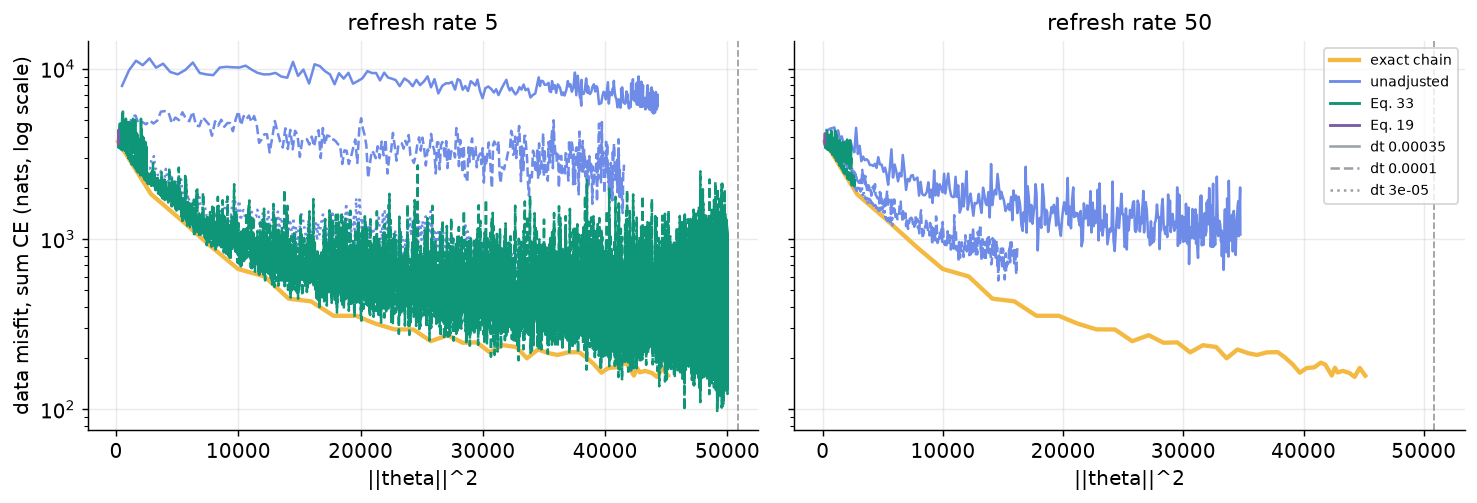

In [24]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
mode_colors = {"unadjusted": BLUE, "Eq. 33": "#0F9678", "Eq. 19": "#7A5EA8"}
dt_styles = {3.5e-4: "-", 1e-4: "--", 3e-5: ":"}
for axis, refresh in zip(axes, (5.0, 50.0)):
    reference = axis.plot(gaussian_norms, gaussian_misfits, color=RT, lw=2.4,
                          label="exact chain")
    for arm in arms:
        if arm["refresh"] != refresh:
            continue
        axis.plot(arm.get("extended_norm", arm["norm"]),
                  arm.get("extended_misfit", arm["misfit"]),
                  color=mode_colors[arm["mode"]],
                  ls=dt_styles[arm["step_size"]], lw=1.4)
    axis.axvline(50890, color=GREY, ls="--", lw=1)
    axis.set_xlabel("||theta||^2")
    axis.set_yscale("log")
    axis.set_title(f"refresh rate {refresh:.0f}")
axes[0].set_ylabel("data misfit, sum CE (nats, log scale)")
handles = [plt.Line2D([], [], color=RT, lw=2.4, label="exact chain"),
           *[plt.Line2D([], [], color=c, lw=1.6, label=m)
             for m, c in mode_colors.items()],
           *[plt.Line2D([], [], color=GREY, ls=s, lw=1.4, label=f"dt {d:g}")
             for d, s in dt_styles.items()]]
axes[1].legend(handles=handles, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

### The paper's tuning recipe, run as written

"Step sizes should be lowered until acceptance rates per Eq. 33 stop improving significantly." The cell below shows that recipe executed with short probe chains: acceptance climbs as the step size shrinks, then hits a plateau near 47%. The plateau is not a property of the step size; it is the noise floor (windows whose verdict is decided by which images landed in the batch), and reaching it is precisely the recipe's stopping signal.

How to read the log below: during tuning, higher Eq. 33 acceptance is better until it stops improving. The recipe stops at the plateau (about 47% here), which is the noise floor: shrinking the step further buys no acceptance and only slows the chain.

In [25]:
print_matching_lines(TABLE_DIR / "exp6_tune33.log", r"tune33")

[tune33 rr=5] dt=0.00035  Eq.33 acceptance=0.15
[tune33 rr=5] dt=0.0002  Eq.33 acceptance=0.37
[tune33 rr=5] dt=0.0001  Eq.33 acceptance=0.45
[tune33 rr=5] dt=5e-05  Eq.33 acceptance=0.47
[tune33 rr=5] chosen dt=0.0001 (acceptance stopped improving below +0.02)
[tune33 rr=50] dt=0.00035  Eq.33 acceptance=0.15
[tune33 rr=50] dt=0.0002  Eq.33 acceptance=0.39
[tune33 rr=50] dt=0.0001  Eq.33 acceptance=0.44
[tune33 rr=50] dt=5e-05  Eq.33 acceptance=0.47
[tune33 rr=50] dt=3e-05  Eq.33 acceptance=0.43
[tune33 rr=50] chosen dt=5e-05 (acceptance stopped improving below +0.02)


### Letting the softened test run to convergence

The gate comparison left one question open: is Eq. 33's rejection tax just slowness, or does it change where the chain ends up? To answer it, the recipe-chosen arm (dt 1e-4, refresh 5) was resumed from its 100,000-step state and extended in 250,000-step legs (`experiments/exp6_minibatch.py converge33`), reusing the arm's stored noise measurement so the gate never changes strength, until the combined march passed the same final-quarter drift rule the exact chains are held to, on both curves at once.

How to read the figure and summary below: the weight norm has no better direction, but arrival means it levels off near (slightly below) the shell, which is where the likelihood-constrained posterior actually lives. For the misfit, lower is better, with the exact chain's 158 as the reference. The verdict applies the drift rule to the whole combined run.

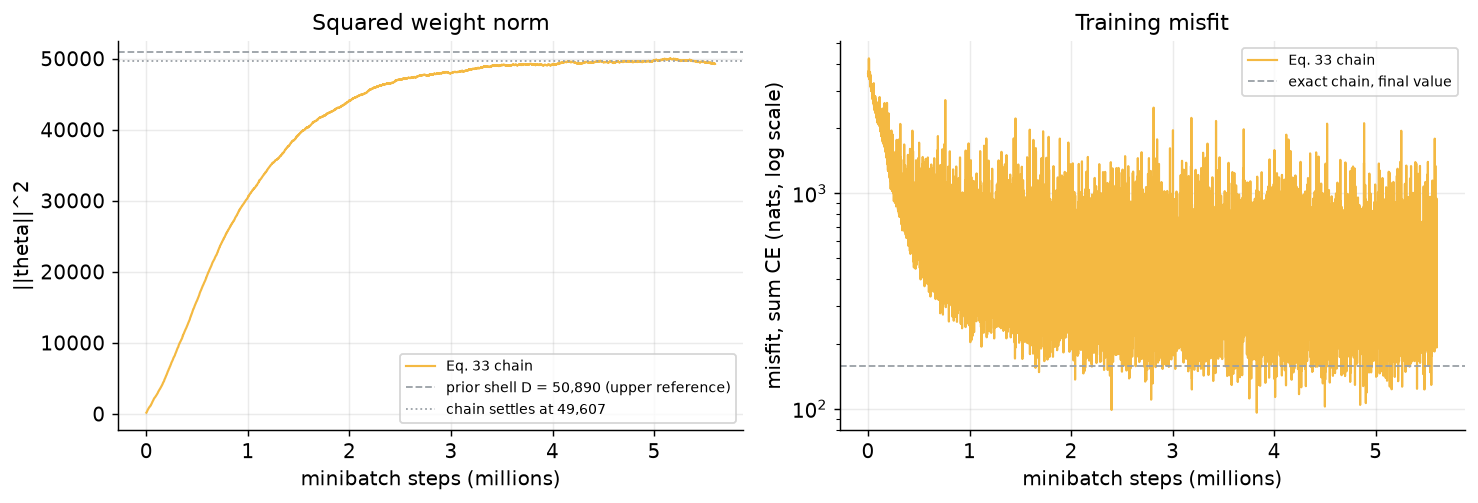

combined run: 5,600,000 minibatch steps
final norm 49,276 (drift +225 vs noise 165), final misfit 323 (drift +15 vs noise 201)
verdict: STATIONARY on both curves
gate rejection: 51% at the start of the march -> 27% once settled
images touched: 1.4B vs the exact chain's 36B (a still-drifting run), 25x fewer


In [26]:
convergence_base = TABLE_DIR / "exp6_mb33_dt0.0001_rr5.npz"
convergence_parts = sorted(
    TABLE_DIR.glob("exp6_mb33_dt0.0001_rr5_part*.npz"),
    key=lambda path: int(path.stem.rsplit("part", 1)[1]))
if convergence_parts:
    step_offset = 0
    steps, misfits, norms, rejections = [], [], [], []
    for path in [convergence_base] + convergence_parts:
        archive = np.load(path)
        steps.append(np.asarray(archive["steps"]) + step_offset)
        step_offset = steps[-1][-1]
        misfits.append(np.asarray(archive["misfit"]))
        norms.append(np.asarray(archive["norm"]))
        rejections.append(1.0 - np.mean(np.asarray(archive["window_accepted"])))
    steps = np.concatenate(steps)
    misfit = np.concatenate(misfits)
    norm = np.concatenate(norms)

    def final_quarter_drift(series):
        quarter = series[3 * len(series) // 4:]
        slope = np.polyfit(np.arange(len(quarter)), quarter, 1)[0]
        return slope * len(quarter), quarter.std()

    figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
    axes[0].plot(steps / 1e6, norm, color=RT, lw=1.2, label="Eq. 33 chain")
    axes[0].axhline(50890, color=GREY, ls="--", lw=1,
                    label="prior shell D = 50,890 (upper reference)")
    settled_level = norm[3 * len(norm) // 4:].mean()
    axes[0].axhline(settled_level, color=GREY, ls=":", lw=1,
                    label=f"chain settles at {settled_level:,.0f}")
    axes[0].set_xlabel("minibatch steps (millions)")
    axes[0].set_ylabel("||theta||^2")
    axes[0].set_title("Squared weight norm")
    axes[0].legend(fontsize=8)
    axes[1].semilogy(steps / 1e6, misfit, color=RT, lw=1.2,
                     label="Eq. 33 chain")
    axes[1].axhline(158, color=GREY, ls="--", lw=1,
                    label="exact chain, final value")
    axes[1].set_xlabel("minibatch steps (millions)")
    axes[1].set_ylabel("misfit, sum CE (nats, log scale)")
    axes[1].set_title("Training misfit")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    norm_drift, norm_noise = final_quarter_drift(norm)
    misfit_drift, misfit_noise = final_quarter_drift(misfit)
    stationary = (abs(norm_drift) < 2 * norm_noise
                  and abs(misfit_drift) < 2 * misfit_noise)
    images_touched = steps[-1] * 256
    exact_images = 20000 * 30 * 60000
    print(f"combined run: {steps[-1]:,} minibatch steps")
    print(f"final norm {norm[-1]:,.0f} (drift {norm_drift:+,.0f} vs noise "
          f"{norm_noise:,.0f}), final misfit {misfit[-1]:,.0f} "
          f"(drift {misfit_drift:+,.0f} vs noise {misfit_noise:,.0f})")
    print("verdict:", "STATIONARY on both curves" if stationary
          else "still in transit")
    print(f"gate rejection: {rejections[0]:.0%} at the start of the march -> "
          f"{rejections[-1]:.0%} once settled")
    print(f"images touched: {images_touched / 1e9:,.1f}B vs the exact chain's "
          f"{exact_images / 1e9:,.0f}B (a still-drifting run), "
          f"{exact_images / images_touched:,.0f}x fewer")
else:
    print("no continuation legs found; run "
          "experiments/exp6_minibatch.py converge33 first")

### The same program on the CNN

The identical pipeline was run on the CNN posterior (D = 12,810): the paper's recipe tuned the step size (it chose dt 1e-4 at refresh 5, with Eq. 33 acceptance plateauing near 62%, a friendlier noise floor than the MLP's 47%), then the arm was extended in 250,000-step legs (`experiments/exp6_minibatch.py cnn33`). How to read the figure and summary below: same rules as the MLP's, the norm should level near (somewhat below) the shell, lower misfit is better, and the printed verdict applies the drift rule to the combined run. The reference line uses the exact CNN chain's last state, itself still in transit at 20,000 trajectories with its norm only about a third of the way to the shell.

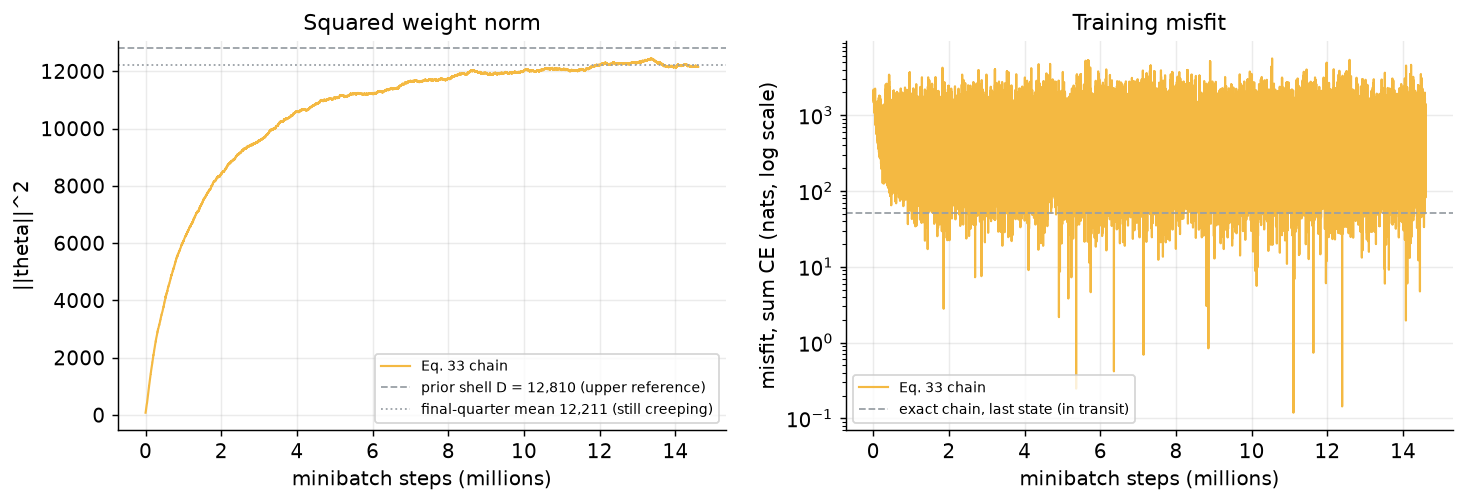

combined run: 14,600,000 minibatch steps
final norm 12,161 of shell 12,810 (drift +176 vs noise 107), final misfit 488 (drift -37 vs noise 504)
verdict: STATIONARY on both curves
gate rejection: 37% at the start -> 55% in the final leg


In [27]:
cnn_convergence_base = TABLE_DIR / "exp6_mb33_cnn_dt0.0001_rr5.npz"
cnn_parts = sorted(TABLE_DIR.glob("exp6_mb33_cnn_dt0.0001_rr5_part*.npz"),
                   key=lambda path: int(path.stem.rsplit("part", 1)[1]))
if cnn_parts:
    step_offset = 0
    steps, misfits, norms, rejections = [], [], [], []
    for path in [cnn_convergence_base] + cnn_parts:
        archive = np.load(path)
        steps.append(np.asarray(archive["steps"]) + step_offset)
        step_offset = steps[-1][-1]
        misfits.append(np.asarray(archive["misfit"]))
        norms.append(np.asarray(archive["norm"]))
        rejections.append(1.0 - np.mean(np.asarray(archive["window_accepted"])))
    steps = np.concatenate(steps)
    misfit = np.concatenate(misfits)
    norm = np.concatenate(norms)
    cnn_shell = sum(parameter.numel()
                    for parameter in ARCHITECTURES["cnn"]().parameters())

    # the exact CNN chain's endpoint for reference (still climbing at 600)
    exact_cnn_reference = None
    if "cnn" in chains:
        reference_model = ARCHITECTURES["cnn"]().to(DEVICE)
        _, reference_unflatten = make_log_posterior(reference_model)
        theta = torch.tensor(np.asarray(chains["cnn"]["samples"][-1]),
                             device=DEVICE)
        parameters = reference_unflatten(theta)
        with torch.no_grad():
            exact_cnn_reference = sum(
                F.cross_entropy(
                    torch.func.functional_call(reference_model, parameters,
                                               (images,)),
                    labels, reduction="sum").item()
                for images, labels in zip(IMAGE_CHUNKS, LABEL_CHUNKS))

    figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
    axes[0].plot(steps / 1e6, norm, color=RT, lw=1.2, label="Eq. 33 chain")
    axes[0].axhline(cnn_shell, color=GREY, ls="--", lw=1,
                    label=f"prior shell D = {cnn_shell:,} (upper reference)")
    final_quarter_level = norm[3 * len(norm) // 4:].mean()
    axes[0].axhline(final_quarter_level, color=GREY, ls=":", lw=1,
                    label=f"final-quarter mean {final_quarter_level:,.0f} "
                          "(still creeping)")
    axes[0].set_xlabel("minibatch steps (millions)")
    axes[0].set_ylabel("||theta||^2")
    axes[0].set_title("Squared weight norm")
    axes[0].legend(fontsize=8)
    axes[1].semilogy(steps / 1e6, misfit, color=RT, lw=1.2,
                     label="Eq. 33 chain")
    if exact_cnn_reference is not None:
        axes[1].axhline(exact_cnn_reference, color=GREY, ls="--", lw=1,
                        label="exact chain, last state (in transit)")
    axes[1].set_xlabel("minibatch steps (millions)")
    axes[1].set_ylabel("misfit, sum CE (nats, log scale)")
    axes[1].set_title("Training misfit")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    def final_quarter_drift(series):
        quarter = series[3 * len(series) // 4:]
        slope = np.polyfit(np.arange(len(quarter)), quarter, 1)[0]
        return slope * len(quarter), quarter.std()

    norm_drift, norm_noise = final_quarter_drift(norm)
    misfit_drift, misfit_noise = final_quarter_drift(misfit)
    stationary = (abs(norm_drift) < 2 * norm_noise
                  and abs(misfit_drift) < 2 * misfit_noise)
    print(f"combined run: {steps[-1]:,} minibatch steps")
    print(f"final norm {norm[-1]:,.0f} of shell {cnn_shell:,} "
          f"(drift {norm_drift:+,.0f} vs noise {norm_noise:,.0f}), "
          f"final misfit {misfit[-1]:,.0f} "
          f"(drift {misfit_drift:+,.0f} vs noise {misfit_noise:,.0f})")
    print("verdict:", "STATIONARY on both curves" if stationary
          else "still in transit")
    print(f"gate rejection: {rejections[0]:.0%} at the start -> "
          f"{rejections[-1]:.0%} in the final leg")
else:
    print("no CNN arm found; run experiments/exp6_minibatch.py cnn33 first")

### The two chains side by side

Same sampler, same recipe-chosen step size, same gate, different architecture. The panels below overlay the two marches on shared axes: the weight norm as a fraction of each chain's own shell (arrival means leveling below 1), the training misfit in nats (directly comparable, same 60,000 images), and the gate's rejection rate per leg, where the two chains trend in opposite directions as they settle. The printed table applies the same drift rule to both.

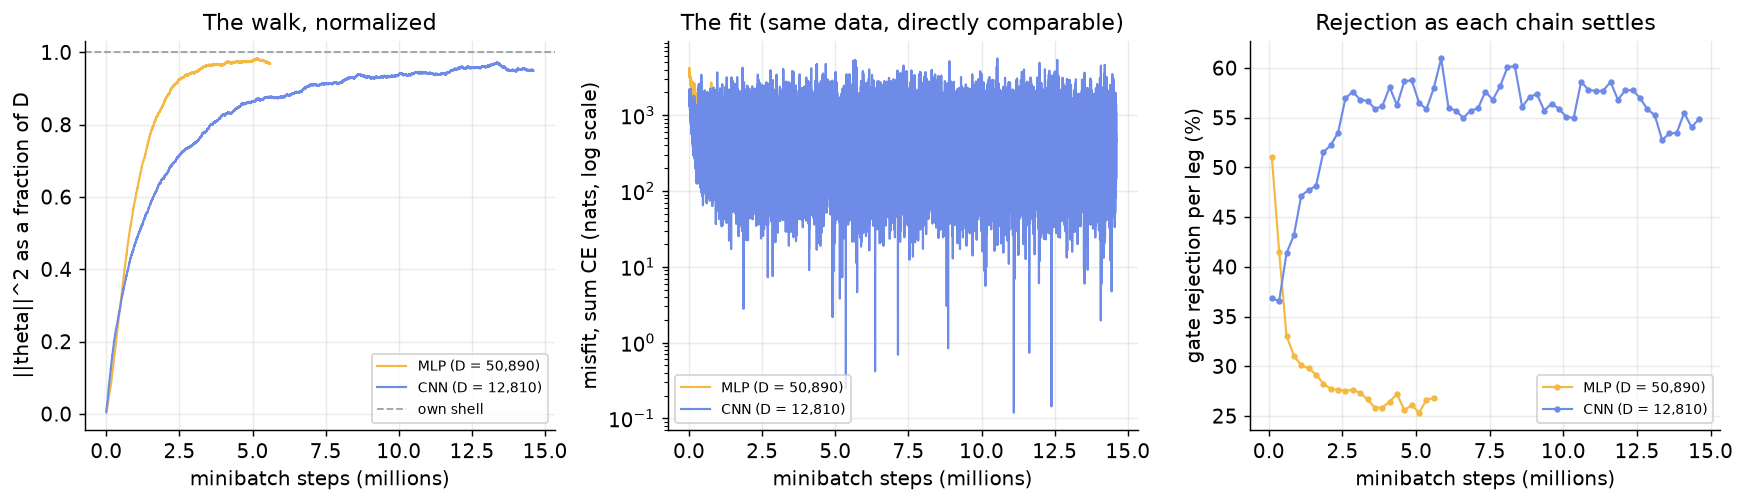

                                        MLP            CNN
                   steps run           5.6M          14.6M
     norm / shell at the end          96.8%          94.9%
         final misfit (nats)            323            488
gate rejection, first -> last leg     51% -> 27%     37% -> 55%
          drift-rule verdict     STATIONARY     STATIONARY


In [28]:
def load_march(stem):
    files = [TABLE_DIR / f"{stem}.npz"] + sorted(
        TABLE_DIR.glob(f"{stem}_part*.npz"),
        key=lambda path: int(path.stem.rsplit("part", 1)[1]))
    if len(files) < 2:
        return None
    step_offset, steps, misfits, norms, rejections, leg_ends = 0, [], [], [], [], []
    for path in files:
        archive = np.load(path)
        steps.append(np.asarray(archive["steps"]) + step_offset)
        step_offset = steps[-1][-1]
        misfits.append(np.asarray(archive["misfit"]))
        norms.append(np.asarray(archive["norm"]))
        rejections.append(1.0 - np.mean(np.asarray(archive["window_accepted"])))
        leg_ends.append(step_offset)
    return (np.concatenate(steps), np.concatenate(misfits),
            np.concatenate(norms), np.array(rejections), np.array(leg_ends))

marches = {"MLP (D = 50,890)": (load_march("exp6_mb33_dt0.0001_rr5"), 50890, RT),
           "CNN (D = 12,810)": (load_march("exp6_mb33_cnn_dt0.0001_rr5"),
                                12810, BLUE)}
if all(m[0] is not None for m in marches.values()):
    figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
    for label, (march, shell, color) in marches.items():
        steps, misfit, norm, rejections, leg_ends = march
        axes[0].plot(steps / 1e6, norm / shell, color=color, lw=1.2,
                     label=label)
        axes[1].semilogy(steps / 1e6, misfit, color=color, lw=1.2,
                         label=label)
        axes[2].plot(leg_ends / 1e6, 100 * rejections, color=color, lw=1.2,
                     marker="o", ms=2.5, label=label)
    axes[0].axhline(1.0, color=GREY, ls="--", lw=1, label="own shell")
    axes[0].set_xlabel("minibatch steps (millions)")
    axes[0].set_ylabel("||theta||^2 as a fraction of D")
    axes[0].set_title("The walk, normalized")
    axes[0].legend(fontsize=8)
    axes[1].set_xlabel("minibatch steps (millions)")
    axes[1].set_ylabel("misfit, sum CE (nats, log scale)")
    axes[1].set_title("The fit (same data, directly comparable)")
    axes[1].legend(fontsize=8)
    axes[2].set_xlabel("minibatch steps (millions)")
    axes[2].set_ylabel("gate rejection per leg (%)")
    axes[2].set_title("Rejection as each chain settles")
    axes[2].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    def final_quarter_drift(series):
        quarter = series[3 * len(series) // 4:]
        slope = np.polyfit(np.arange(len(quarter)), quarter, 1)[0]
        return slope * len(quarter), quarter.std()

    print(f"{'':>28} {'MLP':>14} {'CNN':>14}")
    verdict_columns = []
    for label, (march, shell, _) in marches.items():
        steps, misfit, norm, rejections, _ = march
        norm_drift, norm_noise = final_quarter_drift(norm)
        misfit_drift, misfit_noise = final_quarter_drift(misfit)
        stationary = (abs(norm_drift) < 2 * norm_noise
                      and abs(misfit_drift) < 2 * misfit_noise)
        verdict_columns.append([f"{steps[-1] / 1e6:.1f}M", f"{norm[-1] / shell:.1%}",
                     f"{misfit[-1]:,.0f}",
                     f"{rejections[0]:.0%} -> {rejections[-1]:.0%}",
                     "STATIONARY" if stationary else "in transit"])
    for name, mlp_value, cnn_value in zip(
            ["steps run", "norm / shell at the end", "final misfit (nats)",
             "gate rejection, first -> last leg", "drift-rule verdict"],
            *verdict_columns):
        print(f"{name:>28} {mlp_value:>14} {cnn_value:>14}")

## Findings

**The exact Metropolis test runs cleanly at this scale, at a real but tractable price.** The MLP's full-batch trajectories cost 0.15 s each (20,000 in 51 minutes). The CNN's cost ~16 s each at laptop pilot rate; its production chain is a 20,000-trajectory rerun on a rented RTX 5090 (62 minutes per 2,000-trajectory leg, 10.4 hours; the throttled 600-trajectory laptop run is kept as a backup). The tuned step sizes hold 97 to 99% acceptance, and the step size cliff is razor sharp: a factor of 3 in dt separates near-total acceptance from total rejection. Acceptance is also state dependent: the same MLP step size measured 85% near the point estimate during tuning but realized 97% over the full chain.

**Neither chain reached stationarity, even at 20,000 trajectories, and the decomposition says why.** The MLP chain climbs for roughly 400 trajectories (the Adam checkpoint is not the mode), then descends for the rest of the run, and the two-term split shows the descent is not a failure to sample: the chain *improves* the training fit (sum CE falls from 3,982 nats at the checkpoint to ~160 late in the chain) while the weight norm marches out toward the prior's typical shell ($\lVert\theta\rVert^2$: 174 $\to$ 45,134, heading toward the shell near $D = 50{,}890$). The $T=1$ posterior with an $\mathcal{N}(0,1)$ prior genuinely lives out there. At the training point the prior's log-density term is 46x smaller than the likelihood's (87 vs 3,982 nats), yet the prior controls where the posterior mass is, because volume beats density in 50,890 dimensions. After 600k gradient evaluations the prior cost has covered ~89% of its 25,445-nat climb (a little less in truth: likelihood-constrained directions keep the shell somewhat below $D$) and the trace is still drifting ~2,000 nats per 5,000 trajectories. The CNN's rerun clears its ascent early and then marches: at 20,000 trajectories its norm has covered only about a third of the walk ($\lVert\theta\rVert^2$: 80 $\to$ 4,338 of $D = 12{,}810$), with final-quarter drift $-446$ nats against noise 129. **Survival, and even 97 to 99% acceptance, is not stationarity.**

**ESS is single digit, and that is the honest currency.** Within the flagged windows, $\tau \sim 700$ trajectories for both chains, so 600k gradient evaluations each bought fewer than 10 effective samples. These are upper bounds twice over: the residual trend inflates ESS, and both windows are only 7 $\tau$ long, well under the 50 $\tau$ validity rule for the Sokal estimator, which underestimates $\tau$ on short windows.

**A transient chain reports whatever the transient serves.** The predictive table has two windows of the same MLP chain: the first 2,000 trajectories (samples still near the training point) and the final quarter (samples out on the shell, logits saturated by the large weight norms). They give materially different answers on every metric, and neither is "the posterior predictive", because neither window is stationary. Without the stationarity flag, either could have been presented as the Bayesian result. The 10-seed deep ensemble, by contrast, wins accuracy and NLL cheaply; its spread measures between-mode diversity, a different (and on MNIST, larger) quantity than any within-chain spread. MC dropout sits in between: on the CNN one training run recovers most of the deep ensemble's NLL gain (0.0343 vs 0.0310), while on the 64-unit MLP it lags the plain point estimate even after its rate had to be retuned from 0.5 to 0.25. None of these baselines is tuning-free either.

**The prior comparison settles what the prior does.** Same start, same tuned settings, only the $-\tfrac12\lVert\theta\rVert^2$ term removed: the flat-prior chain's log-likelihood trace flattens toward apparent stationarity (final-quarter drift +21 nats against noise 12) while $\lVert\theta\rVert^2$ grows linearly through 108,797, past double the $\mathcal{N}(0,1)$ shell, with nothing to stop it. The improper posterior has no typical set, and a convergence monitor watching only the target trace would soon be fooled. The prior is the brake; the two chains differ in nothing else. A known-answer check (standard normal, $D=100$) reproduces the analytic moments through the same sampler and test, closing the loop on implementation exactness.

**The minibatch regime, measured against ground truth.** The accept test cannot run on batches: on a real trajectory the true $\Delta \ln L$ was ~12 nats and a batch-256 estimate carried ~267 nats of noise, wrong in sign for 48% of batches. Applied anyway (Eq. 19), the raw test froze every arm at its starting point, rejecting 99.9% of windows. The paper's softened Eq. 33 (exponent $8.8\times10^{-4}$ at the measured $\sigma_{sto} = 1{,}142$ nats) is a working circuit breaker: it stopped the runaway arm (90% rejection, weight norm contained at 2,501 versus 44,292 ungated) but taxed healthy arms with ~47% noise-driven rejections, slowing their march by an order of magnitude, both faces of the paper's own caveat. Unadjusted with tuned knobs was the only mode that actually traveled: at dt 3e-5 with refresh 5 it reached misfit 834 while covering most of the norm march, touching 1/1,400th the images of the exact chain (whose misfit is 158). The knobs behave as the theory says: raising the refresh rate cleans up big-step noise (misfit 7,025 to 1,063 at dt 3.5e-4) at the price of diffusive transport. The paper's own recipe, lower the step size until Eq. 33 acceptance plateaus, ran as written and chose dt 1e-4 (refresh 5) and 5e-5 (refresh 50); the ~47% plateau it detects is the noise floor itself. A follow-up run then settled the open question about the softened test: resumed in legs, the recipe-chosen arm kept marching and, at 5.6 million minibatch steps, became the first chain in this notebook to formally pass the stationarity rule, its weight norm leveling just below the shell (as the likelihood-constrained geometry predicts) and its misfit settling around the exact chain's band, while touching about 25x fewer images than the exact chain's still-drifting 20,000 trajectories. The gate's tax is real, roughly 40x the transport of an untested chain, but it is a time tax, not a bias: Eq. 33 slowed the trip without corrupting the destination. Its posterior predictive, added to the step 5 table, is the first look at this posterior actually at equilibrium: accuracy 0.9744, a hair above the point estimate, with NLL 0.158, far better than the in-transit exact chain's late window (0.265) but still behind the point estimate and the deep ensemble. The equilibrium posterior is more benign than the transient made it look, and the cold posterior tension survives a converged chain. As an error detector at a matched review budget, the converged posterior's disagreement catches 90% of its own test errors at 75x enrichment, beating the point estimate's raw confidence (86%, 52x) but not the deep ensemble's spread (92%, 93x): on MNIST every uncertainty signal works, and the ordering is the news. Two more cuts sharpen it. Member-count scaling shows the two kinds of ensemble are opposites: one deep-ensemble member already reaches NLL 0.099 and two nearly saturate it (0.084), while individual posterior samples are poor (0.68 alone) and averaging keeps buying improvement all the way to 50 members (0.158, still falling): ensemble members are redundant excellence, posterior samples are accumulating evidence, and the predictive integral has not saturated at 50. And the flagged sets only half-overlap (Jaccard 0.40 to 0.52), so the signals are not interchangeable: each flags hard images the others miss. Fake images then expose who is overconfident: shown inverted digits, the point estimate stays 80% confident and flags only three quarters of them, and MC dropout misses half of pure noise outright. The deep ensemble is the most honest (median confidence 0.34 on inverted digits, AUROC 1.00). The surprise is the converged chain: its averaged prediction stays fairly confident on fakes, the shell's saturation showing through, but its members' disagreement is the most consistent detector in the study (98% of noise, 93% of inverted digits, and 88% of Fashion-MNIST flagged, the best of any method on that hardest set). Confidence and disagreement decouple: the posterior predictive can be overconfident while the posterior spread still knows something is wrong. The same program on the CNN (D = 12,810) sharpened the picture: the recipe chose the same step size at a friendlier noise floor (Eq. 33 acceptance plateauing near 62%), the misfit reached the exact chain's scale within the first two million steps and stayed level, but the weight norm kept creeping until, at 14.6 million minibatch steps, both curves passed the drift rule: STATIONARY, settled at 94.9% of the shell. The same rule the MLP passed at 5.6 million steps took the CNN nearly three times as long, all of it in the norm's slow tail. The contrast is architectural. The CNN's likelihood constrains a larger share of its directions, so its equilibrium sits farther below the naive shell and its approach carries a much longer tail; the drift rule detects each chain's own equilibrium rather than assuming the shell is the destination. The two chains' gate rejection rates even trend in opposite directions as they settle (MLP 51% down to 27%, CNN 37% up to 55%), one more sign the noise floor is state and architecture dependent. And the CNN chain's converged predictive, added to the step 5 table, is the strongest chain result in the study: 98.92% accuracy, essentially the deep ensemble's 99.04% and half a point above its own point estimate, at NLL 0.085 with ECE 0.0033, a far milder saturation penalty than the MLP's shell posterior paid. The path of that number is its own small lesson: it read 0.0715 at 12.1 million steps, drifted upward through the norm creep, and settled at 0.0854 once the chain passed the drift rule, so the in-transit caveat attached to the earlier reading was doing real work. The architecture whose likelihood grips its geometry hardest also yields the most benign posterior.

**The Adam start is load-bearing, and the two jobs of burn-in are not symmetric.** Two more chains at the same target and budget, different starts. From a fresh random initialization (chance level, misfit 137,570 nats) the tuned step drops 12x and the chain spends its entire 20,000 trajectories on the fit job, ending at misfit 4,114 and norm 872: roughly the Adam checkpoint's neighborhood, with the whole prior walk still ahead. In data touched, that is the sampler redoing Adam's ~300 thousand image evaluations with 36 billion. From a prior draw (norm already on the shell, but saturated and confidently wrong at 17.3 million nats of misfit) only a step 350x below the Adam tuning moves at all, and after the same budget the chain still carries 3.2 million nats of misfit while its norm has not left the shell it started on. Starting at the right norm bought nothing: fit difficulty dictates the step size, and the step size dictates everything else. From a good fit, burn-in is the prior walk; from anywhere else, fitting dominates, and the trained start is what makes the expensive job disappear.\n\n**What this means for the auto-tune agenda.** Acceptance alone is a bad tuning target: it sat at 97 to 99% while both chains were far from equilibrium. A tuner must watch the log-posterior trend and its likelihood/prior decomposition; the stationarity flag above is a first version, and the flat-prior chain shows why the decomposition must be part of it. The shadow rejection rate (the exact test demoted from gatekeeper to gauge) is the right idea but saturates at 250-step windows: every unadjusted arm scores near 100% while their marches differ enormously, so the usable form of that instrument needs finer windows. What discriminates arms today is the march itself, misfit and weight norm against the exact chain. The knobs that actually matter here: trajectory length (cost linear in $L$, distance per trajectory grows with it), multiple chains for between-chain diagnostics, and above all the temperature and prior scale. The $T=1$, $\mathcal{N}(0,1)$ posterior of an unregularized 50k-parameter net concentrates on saturated networks far from the training point; this is the cold posterior tension made concrete in one notebook, and it is why tempering (the paper's $W$ dial) is a research direction and not a footnote. One implementation caution for that direction: the vendored accept test is exact only at `scale_likelihood = 1`, the setting used here, so tempering through that knob without adjusting the test would silently break exactness.

## Result figures

Three presentation figures built from the objects computed above, shown inline and saved to `results/figures/` for slides. The theme colors are snapped to darker steps that pass the accessibility checks on a white surface (lightness band, chroma floor, colorblind separation, 3:1 contrast). The ray tracing chain keeps its gold; where two windows of the same chain appear together, they share the gold and a hatch texture tells them apart.

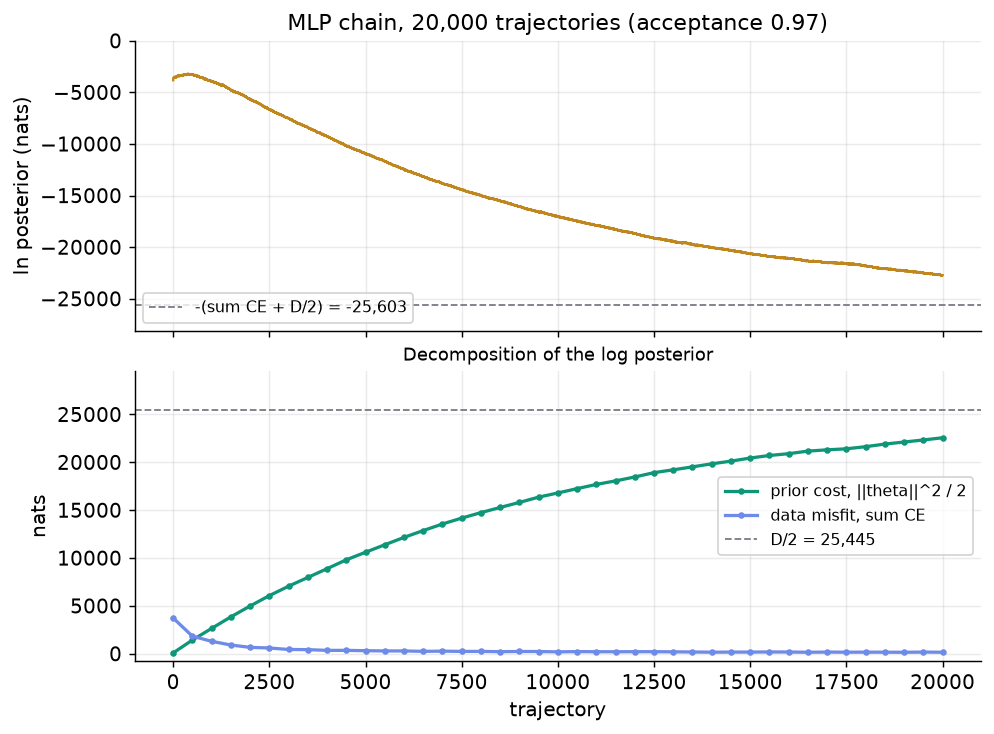

In [29]:
FIGURE_DIR = Path("results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# theme hues, darkened to pass the accessibility checks on white
GOLD, LIKELIHOOD_BLUE, POINT_PURPLE, PRIOR_TEAL = ("#C0871F", "#6E8BE8",
                                                   "#7A5EA8", "#0F9678")
INK, MUTED = "#2b2b33", "#7a7a85"

# figure 1: the march to the prior shell (MLP), trace + decomposition
if "mlp" in chains:
    chain = chains["mlp"]
    trace = chain["log_posterior_trace"]
    dimension = chain["samples"].shape[1]

    sample_indices = np.linspace(0, chain["n_trajectories"] - 1, 41).astype(int)
    misfits, prior_costs = [], []
    for k in sample_indices:
        theta = torch.tensor(np.asarray(chain["samples"][k]), device=DEVICE)
        misfit, squared_norm = decompose(theta)
        misfits.append(misfit)
        prior_costs.append(squared_norm / 2)
    misfits, prior_costs = np.array(misfits), np.array(prior_costs)

    figure, (top, bottom) = plt.subplots(
        2, 1, figsize=(8.4, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [1, 1], "hspace": 0.14})

    top.plot(trace, color=GOLD, lw=1.3)
    predicted_typical_set = -(misfits[-1] + dimension / 2)
    top.axhline(predicted_typical_set, color=MUTED, ls="--", lw=1,
                label=f"-(sum CE + D/2) = {predicted_typical_set:,.0f}")
    top.legend(fontsize=9, loc="lower left")
    top.set_ylim(predicted_typical_set - 2500, 0)
    top.set_ylabel("ln posterior (nats)")
    top.set_title(f"MLP chain, {chain['n_trajectories']:,} trajectories "
                  f"(acceptance {chain['acceptance']:.2f})")

    bottom.plot(sample_indices, prior_costs, color=PRIOR_TEAL, lw=1.8,
                marker="o", ms=2.6, label="prior cost, ||theta||^2 / 2")
    bottom.plot(sample_indices, misfits, color=LIKELIHOOD_BLUE, lw=1.8,
                marker="o", ms=2.6, label="data misfit, sum CE")
    bottom.axhline(dimension / 2, color=MUTED, ls="--", lw=1,
                   label=f"D/2 = {dimension // 2:,}")
    bottom.legend(fontsize=9)
    bottom.set_ylim(-800, 29500)
    bottom.set_xlabel("trajectory")
    bottom.set_ylabel("nats")
    bottom.set_title("Decomposition of the log posterior", fontsize=10)

    figure.savefig(FIGURE_DIR / "exp6_fig1_march.png", dpi=200,
                   bbox_inches="tight")
    plt.show()

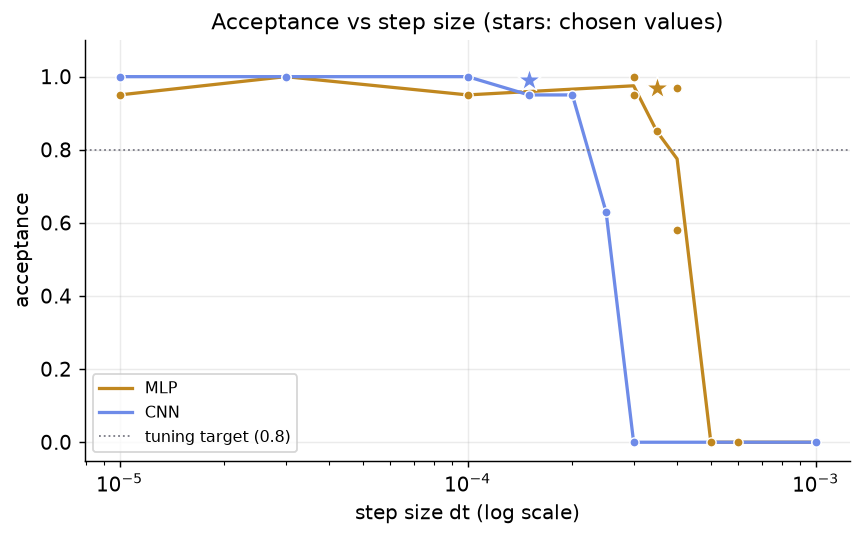

In [30]:
# figure 2: the acceptance cliff (all measured points, both models)
measured = {"mlp": [], "cnn": []}
for line in (TABLE_DIR / "exp6_pilot.log").read_text().splitlines():
    match = re.search(r"\[(mlp|cnn)\] L= 30 dt=(\S+)\s+acc=([\d.]+)", line)
    if match:
        measured[match.group(1)].append((float(match.group(2)),
                                         float(match.group(3))))
for line in (TABLE_DIR / "exp6_auto.log").read_text().splitlines():
    match = re.search(r"\[tune:(mlp|cnn)\] dt=(\S+) acc=([\d.]+)", line)
    if match:
        measured[match.group(1)].append((float(match.group(2)),
                                         float(match.group(3))))
# the far side of the MLP cliff, measured by the first tuner pass
# (its log file was later overwritten by the rerun):
measured["mlp"] += [(4e-4, 0.58), (5e-4, 0.0), (6e-4, 0.0)]

chosen = {"mlp": (3.5e-4, 0.97), "cnn": (1.5e-4, 0.99)}
model_colors = {"mlp": GOLD, "cnn": LIKELIHOOD_BLUE}

figure, axis = plt.subplots(figsize=(7.6, 4.2))
for name in ("mlp", "cnn"):
    points = np.array(sorted(measured[name]))
    step_sizes = np.unique(points[:, 0])
    mean_acceptance = [points[points[:, 0] == s, 1].mean() for s in step_sizes]
    axis.plot(step_sizes, mean_acceptance, color=model_colors[name], lw=1.8,
              zorder=2, label=name.upper())
    axis.scatter(points[:, 0], points[:, 1], s=26, color=model_colors[name],
                 zorder=3, edgecolors="white", linewidths=0.8)
    axis.scatter([chosen[name][0]], [chosen[name][1]], marker="*", s=180,
                 color=model_colors[name], zorder=4, edgecolors="white",
                 linewidths=0.8)
axis.axhline(0.8, color=MUTED, ls=":", lw=1, label="tuning target (0.8)")
axis.legend(fontsize=9, loc="lower left")
axis.set_xscale("log")
axis.set_xlabel("step size dt (log scale)")
axis.set_ylabel("acceptance")
axis.set_ylim(-0.05, 1.1)
axis.set_title("Acceptance vs step size (stars: chosen values)")
figure.savefig(FIGURE_DIR / "exp6_fig2_cliff.png", dpi=200, bbox_inches="tight")
plt.show()

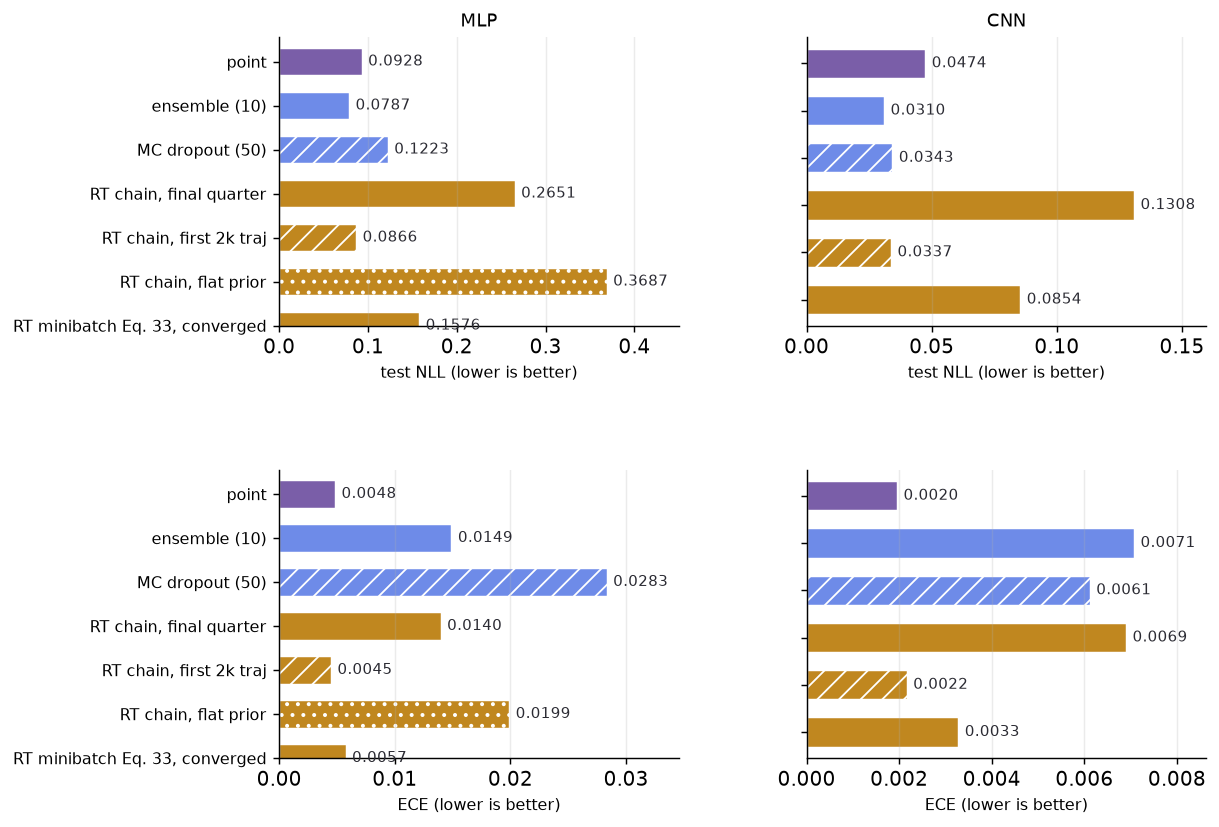

In [31]:
# figure 3: the predictive comparison, built from the `rows` table above
def bar_style(label):
    if label == "point":
        return POINT_PURPLE, ""
    if label.startswith("ensemble"):
        return LIKELIHOOD_BLUE, ""
    if label.startswith("MC dropout"):
        return LIKELIHOOD_BLUE, "//"   # ensemble family, single-model variant
    if "first 2k" in label:
        return GOLD, "//"          # same entity as the chain, other window
    if "flat prior" in label:
        return GOLD, ".."          # same sampler, the other prior
    return GOLD, ""

figure, axes = plt.subplots(2, 2, figsize=(9.2, 7.2),
                            gridspec_kw={"hspace": 0.5, "wspace": 0.32})
for column, model_name in enumerate(("mlp", "cnn")):
    model_rows = [row for row in rows if row[0] == model_name]
    names = [row[1] for row in model_rows]
    metric_values = {"test NLL": [row[3] for row in model_rows],
                     "ECE": [row[4] for row in model_rows]}
    for row_index, (metric, values) in enumerate(metric_values.items()):
        axis = axes[row_index][column]
        # top-align rows across columns so bars line up with the shared labels
        y_positions = 5 - np.arange(len(model_rows))
        for y, value, label in zip(y_positions, values, names):
            color, hatch = bar_style(label)
            axis.barh(y, value, height=0.62, color=color, hatch=hatch,
                      edgecolor="white", linewidth=0.8)
            axis.text(value + max(values) * 0.02, y, f"{value:.4f}",
                      va="center", fontsize=8.5, color=INK)
        axis.set_ylim(-0.55, 5.55)
        axis.set_yticks(y_positions)
        axis.set_yticklabels(names if column == 0 else [""] * len(model_rows),
                             fontsize=9)
        axis.set_xlim(0, max(values) * 1.22)
        axis.set_xlabel(f"{metric} (lower is better)", fontsize=9)
        axis.grid(axis="y", visible=False)
        if row_index == 0:
            axis.set_title(model_name.upper(), fontsize=10)
figure.savefig(FIGURE_DIR / "exp6_fig3_predictive.png", dpi=200,
               bbox_inches="tight")
plt.show()